In [1]:
import pandas as pd

df = pd.read_csv("/users/framunno/data/ionosphere/l1_to_map_matched_even_minutes_test_v3.csv")


from pathlib import Path
from datetime import datetime, timedelta

def extract_timestamp(filename):
    base = Path(filename).stem
    parts = base.split('_')
    try:
        dt = datetime(
            int(parts[-6]), int(parts[-5]), int(parts[-4]),
            int(parts[-3]), int(parts[-2]), int(parts[-1])
        )
    except Exception:
        dt = None
    return dt
	
	
df['timestamp'] = df['filename'].apply(extract_timestamp)
df = df.dropna(subset=['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)

In [2]:
df.head()

,time,proton_vx_gsm,bx_gsm,by_gsm,bz_gsm,speed_kms,delay_min,earth_time,time_map,dt_diff,filename,timestamp
0,2024-01-01 00:11:00+00:00,-426.0,3.85,-3.06,-2.14,426.0,58.685446,2024-01-01 01:09:41.126761+00:00,2024-01-01 01:10:00,0 days 00:00:18.873239,map_2024_1_1_1_10_0.npy,2024-01-01 01:10:00
1,2024-01-01 00:04:00+00:00,-364.4,3.23,-2.09,-3.22,364.4,68.605928,2024-01-01 01:12:36.355653+00:00,2024-01-01 01:12:00,-1 days +23:59:23.644347,map_2024_1_1_1_12_0.npy,2024-01-01 01:12:00
2,2024-01-01 00:10:00+00:00,-383.2,3.72,-3.44,-1.73,383.2,65.240083,2024-01-01 01:15:14.405010+00:00,2024-01-01 01:16:00,0 days 00:00:45.594990,map_2024_1_1_1_16_0.npy,2024-01-01 01:16:00
3,2024-01-01 00:12:00+00:00,-366.5,4.15,-2.59,-2.24,366.5,68.212824,2024-01-01 01:20:12.769441+00:00,2024-01-01 01:20:00,-1 days +23:59:47.230559,map_2024_1_1_1_20_0.npy,2024-01-01 01:20:00
4,2024-01-01 00:00:00+00:00,-306.2,3.51,-3.62,-1.44,306.2,81.645983,2024-01-01 01:21:38.758981+00:00,2024-01-01 01:22:00,0 days 00:00:21.241019,map_2024_1_1_1_22_0.npy,2024-01-01 01:22:00


In [2]:
df.columns

Index(['time', 'proton_vx_gsm', 'bx_gsm', 'by_gsm', 'bz_gsm', 'speed_kms',
       'delay_min', 'earth_time', 'time_map', 'dt_diff', 'filename',
       'timestamp'],
      dtype='object')

In [14]:
import pandas as pd
import os
from datetime import datetime

# ============================================================================
# Analyze ORIGINAL matched CSV (with duplicates)
# ============================================================================

df = pd.read_csv('/users/framunno/data/ionosphere/l1_to_map_matched_even_minutes_test_v3_deduplicated.csv')

print("="*80)
print("ORIGINAL MATCHED CSV ANALYSIS")
print("="*80)

# Extract map timestamp from filename
def extract_timestamp(filename):
    parts = filename.replace('.npy', '').replace('map_', '').split('_')
    try:
        year, month, day, hour, minute, second = parts[0:6]
        return datetime(int(year), int(month), int(day), int(hour), int(minute), int(second))
    except:
        return None

df['map_time'] = df['filename'].apply(extract_timestamp)

# Sep-Oct data
df_valid = df[(df['map_time'].dt.month >= 9) & (df['map_time'].dt.month <= 10)]

print(f"\nTotal rows (Sep-Oct): {len(df_valid):,}")
print(f"Unique maps (Sep-Oct): {df_valid['filename'].nunique():,}")
print(f"Duplicate rows: {len(df_valid) - df_valid['filename'].nunique():,}")

# ============================================================================
# How many maps EXIST in directory?
# ============================================================================

map_dir = '/users/framunno/data/ionosphere/ionosphere_data/pickled_maps/'
all_maps = [f for f in os.listdir(map_dir) if f.endswith('.npy')]

sep_oct_available = [f for f in all_maps if extract_timestamp(f) and
                    extract_timestamp(f).month in [9, 10] and
                    extract_timestamp(f).year == 2024]

print(f"\nMaps available in directory: {len(sep_oct_available):,}")
print(f"Maps matched in CSV: {df_valid['filename'].nunique():,}")
print(f"**MISSING from CSV: {len(sep_oct_available) - df_valid['filename'].nunique():,}**")

# ============================================================================
# Find which maps are missing
# ============================================================================

csv_maps = set(df_valid['filename'].unique())
available_maps = set(sep_oct_available)
missing = available_maps - csv_maps

print(f"\n{'='*80}")
print(f"WHY ARE {len(missing):,} MAPS MISSING FROM MATCHED CSV?")
print(f"{'='*80}")
print("\nFirst 30 missing maps:")
for f in sorted(missing)[:30]:
    print(f"  {f}")

print("\n**This is your bottleneck!**")
print("These maps exist but didn't get matched to L1 data.")
print("Likely reason: No valid L1 measurement within 5-minute tolerance")

ORIGINAL MATCHED CSV ANALYSIS

Total rows (Sep-Oct): 39,055
Unique maps (Sep-Oct): 39,055
Duplicate rows: 0

Maps available in directory: 43,859
Maps matched in CSV: 39,055
**MISSING from CSV: 4,804**

WHY ARE 4,804 MAPS MISSING FROM MATCHED CSV?

First 30 missing maps:
  map_2024_10_10_10_26_0.npy
  map_2024_10_10_10_46_0.npy
  map_2024_10_10_11_12_0.npy
  map_2024_10_10_11_20_0.npy
  map_2024_10_10_11_2_0.npy
  map_2024_10_10_12_22_0.npy
  map_2024_10_10_12_26_0.npy
  map_2024_10_10_14_18_0.npy
  map_2024_10_10_22_44_0.npy
  map_2024_10_10_22_46_0.npy
  map_2024_10_10_22_56_0.npy
  map_2024_10_10_22_58_0.npy
  map_2024_10_10_23_0_0.npy
  map_2024_10_10_23_26_0.npy
  map_2024_10_10_23_28_0.npy
  map_2024_10_10_2_24_0.npy
  map_2024_10_10_4_0_0.npy
  map_2024_10_10_4_10_0.npy
  map_2024_10_10_4_12_0.npy
  map_2024_10_10_4_14_0.npy
  map_2024_10_10_4_16_0.npy
  map_2024_10_10_4_18_0.npy
  map_2024_10_10_4_20_0.npy
  map_2024_10_10_4_22_0.npy
  map_2024_10_10_4_24_0.npy
  map_2024_10_10_

In [6]:
import pandas as pd
from datetime import datetime

# Check L1 data for Oct 10, 2024
l1_df = pd.read_csv('/users/framunno/data/ionosphere/combined_f1m_m1m_2024.csv')
l1_df['time'] = pd.to_datetime(l1_df['time'])

oct_10 = l1_df[l1_df['time'].dt.date == pd.Timestamp('2024-10-10').date()]

print(f"Oct 10 L1 records: {len(oct_10):,}")
print(f"Date range: {oct_10['time'].min()} to {oct_10['time'].max()}")

# Check for valid conditions
def is_valid_row(row):
    for col in ['proton_vx_gsm', 'bx_gsm', 'by_gsm', 'bz_gsm']:
        val = row[col]
        if pd.isna(val) or val == 99999 or val == -99999:
            return False
    return True

oct_10['valid'] = oct_10.apply(is_valid_row, axis=1)
print(f"Valid L1 records: {oct_10['valid'].sum():,}")
print(f"Invalid records: {(~oct_10['valid']).sum():,}")

# Show gaps
oct_10_valid = oct_10[oct_10['valid']].sort_values('time')
print("\nFirst 20 valid L1 times on Oct 10:")
print(oct_10_valid['time'].head(20).values)

print("\n" + "="*80)
print("SOLUTION OPTIONS:")
print("="*80)
print("1. Increase matching tolerance from 5 min to 15 min")
print("2. Use median L1 values for missing maps")
print("3. Accept 2,357 sequences (still decent for validation)")
print("4. Use only_complete_sequences=False and pad with zeros")

Oct 10 L1 records: 1,440
Date range: 2024-10-10 00:00:00+00:00 to 2024-10-10 23:59:00+00:00
Valid L1 records: 1,272
Invalid records: 168

First 20 valid L1 times on Oct 10:
['2024-10-10T00:00:00.000000000' '2024-10-10T00:01:00.000000000'
 '2024-10-10T00:02:00.000000000' '2024-10-10T00:03:00.000000000'
 '2024-10-10T00:04:00.000000000' '2024-10-10T00:05:00.000000000'
 '2024-10-10T00:06:00.000000000' '2024-10-10T00:07:00.000000000'
 '2024-10-10T00:08:00.000000000' '2024-10-10T00:09:00.000000000'
 '2024-10-10T00:10:00.000000000' '2024-10-10T00:11:00.000000000'
 '2024-10-10T00:12:00.000000000' '2024-10-10T00:13:00.000000000'
 '2024-10-10T00:14:00.000000000' '2024-10-10T00:15:00.000000000'
 '2024-10-10T00:16:00.000000000' '2024-10-10T00:17:00.000000000'
 '2024-10-10T00:18:00.000000000' '2024-10-10T00:19:00.000000000']

SOLUTION OPTIONS:
1. Increase matching tolerance from 5 min to 15 min
2. Use median L1 values for missing maps
3. Accept 2,357 sequences (still decent for validation)
4. Use o

/tmp/ipykernel_153787/3920112294.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  oct_10['valid'] = oct_10.apply(is_valid_row, axis=1)


In [2]:
import sys
sys.path.append('/users/framunno/projects/ionosphere_diffusion/src')
from data.dataset import IonoSequenceIterableDataset

# Test with deduplicated CSV
dataset = IonoSequenceIterableDataset(
    csv_path='/users/framunno/data/ionosphere/l1_to_map_matched_even_minutes_test_v3_interpolated_deduplicated.csv',
    sequence_length=30,
    split='train',
    only_complete_sequences=True,
    min_center_distance=1,
    use_l1_conditions=True,
    transforms=False,
    seed=42
)



Building L1 conditions cache for train split...
Cached L1 conditions for 240634 files
Filtered sequences for train: 163059 -> 93567 (57.4% complete)
IonoSequenceIterableDataset [train]: 93567 sequences
  GPU rank: 0/1, Shuffle: True


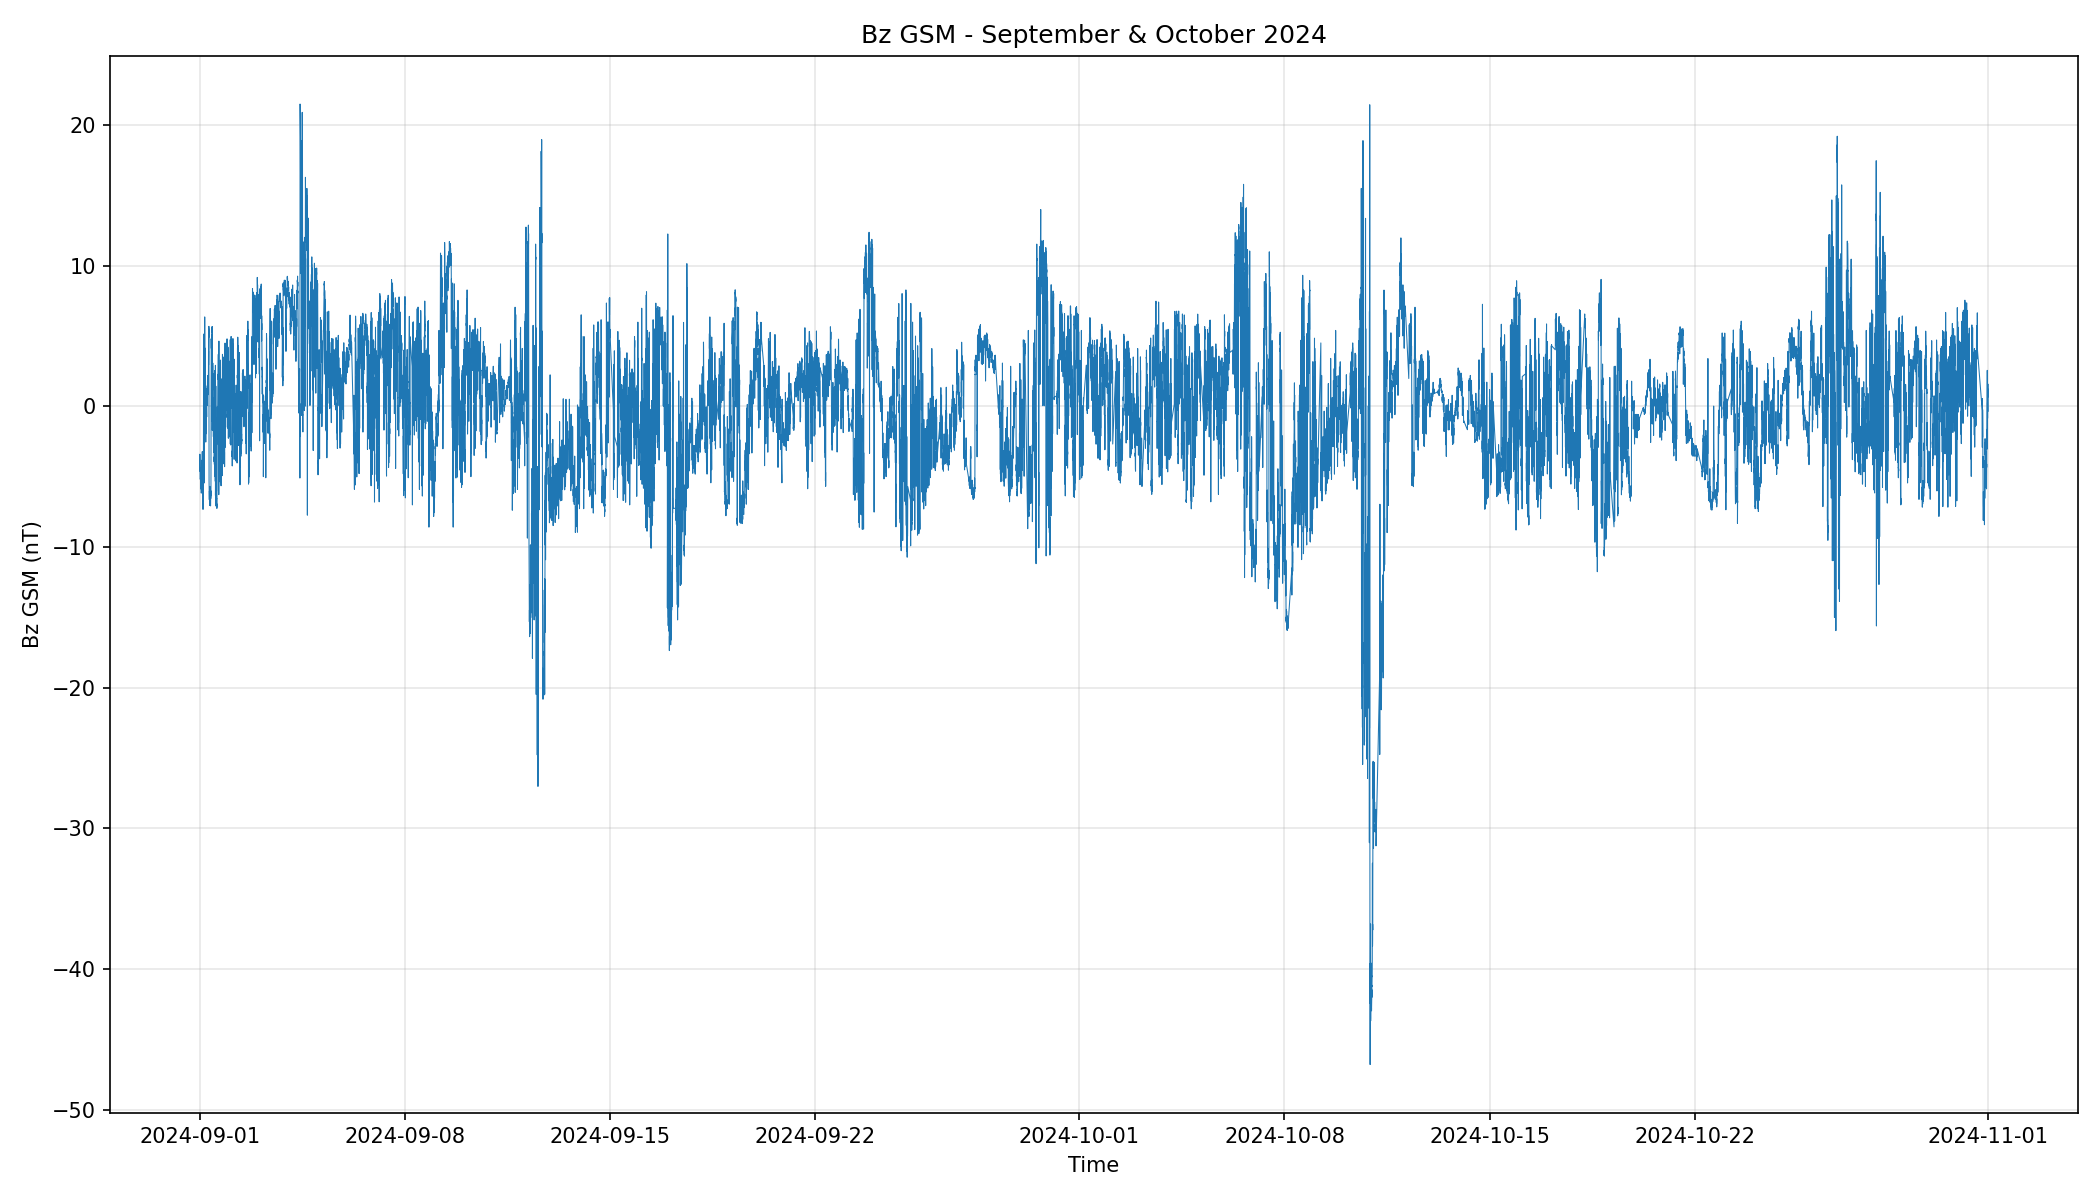

In [33]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib
matplotlib.use("Agg")
from PIL import Image

# Convert time column to datetime if not already
df['time'] = pd.to_datetime(df['time'])

# Filter for September (month 9) and October (month 10)
df_filtered = df[df['time'].dt.month.isin([9, 10])].copy()
# df_filtered = df.copy()
# Sort by time to ensure proper plotting
df_filtered = df_filtered.sort_values('time')

# Create figure with single subplot
fig, ax = plt.subplots(1, 1, figsize=(14, 8))

# Plot bz_gsm
ax.plot(df_filtered['time'], df_filtered['bz_gsm'], linewidth=0.5)
ax.set_xlabel('Time')
ax.set_ylabel('Bz GSM (nT)')
ax.set_title('Bz GSM - September & October 2024')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/users/framunno/visual_res/bz_gsm_plot.png', dpi=150)  # Save instead of show since using Agg backend
plt.close()

Image.open("/users/framunno/visual_res/bz_gsm_plot.png")

In [34]:
import numpy as np

def epsilon_parameter(vwind, by, bz, l0=7e6):  # l0 in meters (7 RE)
    """
    Calculate Akasofu epsilon parameter
    
    Parameters:
    - vwind: solar wind velocity (m/s or km/s)
    - by, bz: IMF components (nT)
    - l0: coupling length scale (default 7 Earth radii in meters)
    
    Returns: epsilon in Watts
    """
    mu0 = 4 * np.pi * 1e-7  # permeability of free space

    # Calculate IMF magnitude and clock angle
    B_perp = np.sqrt(by**2 + bz**2)  # perpendicular component
    theta = np.arctan2(by, bz)  # clock angle

    # Epsilon formula
    epsilon = (vwind * B_perp**2 * l0**2 * np.sin(theta/2)**4) / mu0

    return epsilon

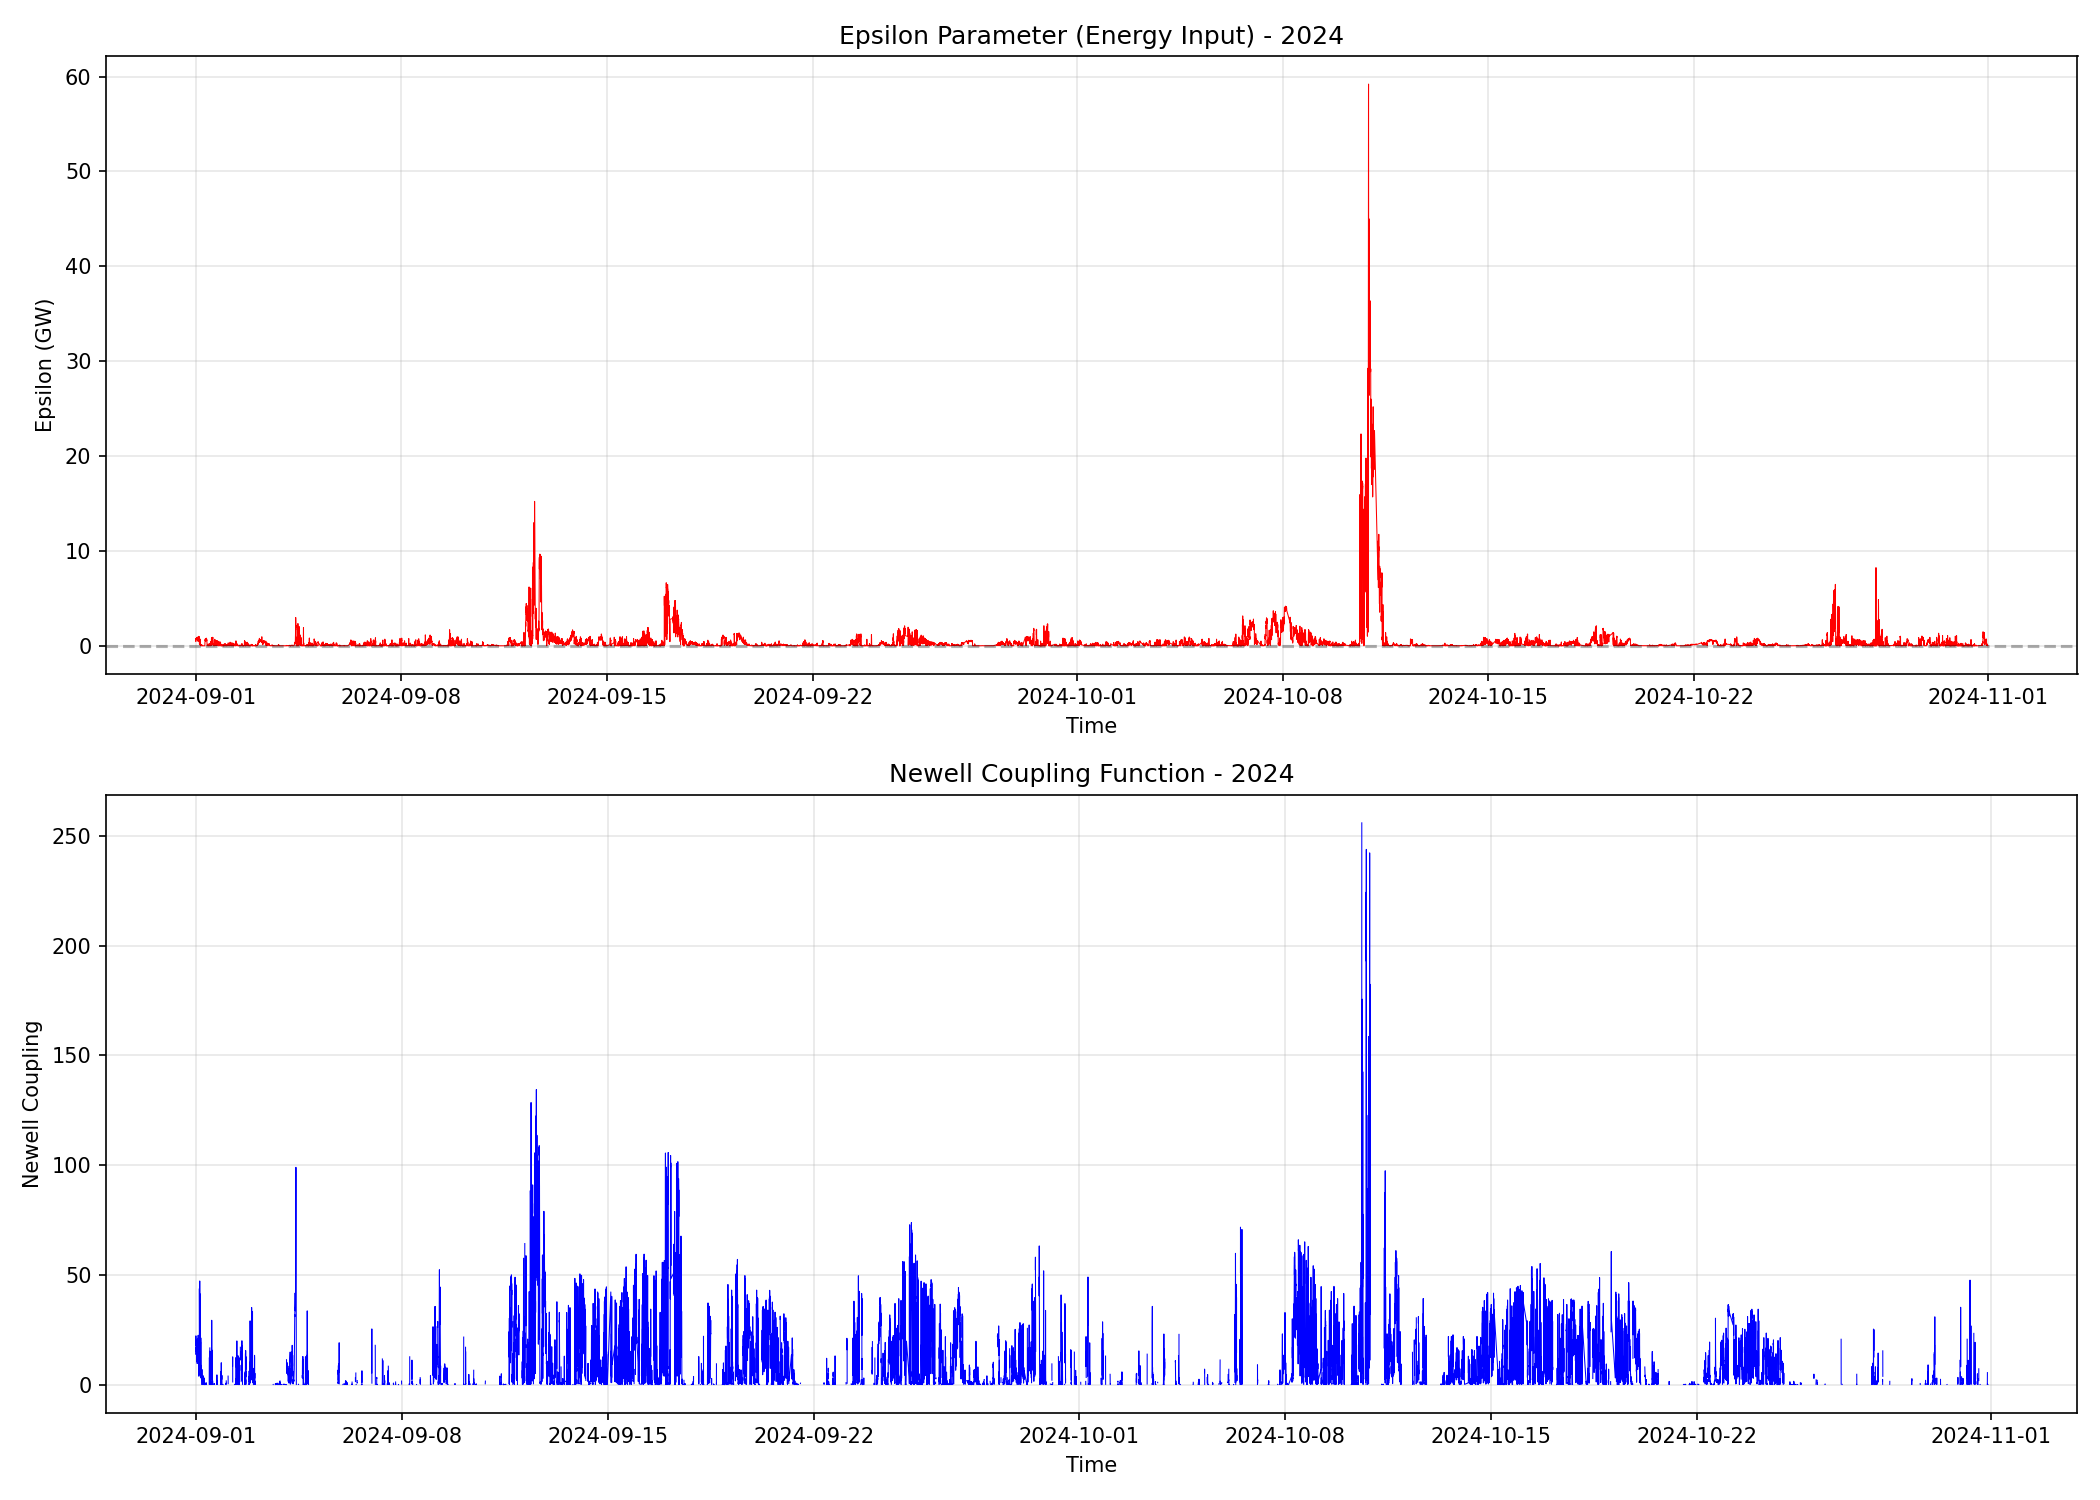

In [35]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use("Agg")
from PIL import Image

# Convert time column to datetime if not already
df['time'] = pd.to_datetime(df['time'])

# Filter for September and October
df_filtered = df[df['time'].dt.month.isin([9, 10])].copy()
# df_filtered = df.copy()
df_filtered = df_filtered.sort_values('time')

# ============= CALCULATE EPSILON PARAMETER =============
def epsilon_parameter(vwind_kms, by, bz, l0=7e6):
    """
    Akasofu epsilon parameter
    
    Parameters:
    - vwind_kms: solar wind velocity in km/s
    - by, bz: IMF components in nT
    - l0: coupling length (7 Earth radii in meters)
    
    Returns: epsilon in GW (GigaWatts)
    """
    mu0 = 4 * np.pi * 1e-7  # permeability

    # Convert velocity to m/s
    vwind = vwind_kms * 1000

    # Convert nT to Tesla
    by_T = by * 1e-9
    bz_T = bz * 1e-9

    # Calculate perpendicular IMF and clock angle
    B_perp = np.sqrt(by_T**2 + bz_T**2)
    theta = np.arctan2(by_T, bz_T)

    # Epsilon formula
    epsilon = (vwind * B_perp**2 * l0**2 * np.sin(theta/2)**4) / mu0

    # Convert to GW for readability
    return epsilon / 1e9

# Calculate epsilon
df_filtered['epsilon_GW'] = epsilon_parameter(
    df_filtered['speed_kms'],
    df_filtered['by_gsm'],
    df_filtered['bz_gsm']
)

# ============= CALCULATE NEWELL COUPLING FUNCTION =============
def newell_coupling(vwind_kms, by, bz):
    """
    Newell et al. (2007) coupling function
    
    Parameters:
    - vwind_kms: solar wind velocity in km/s
    - by, bz: IMF components in nT
    
    Returns: dFlux/dt coupling parameter
    """
    # Convert to m/s
    vwind = vwind_kms * 1000

    # Convert to Tesla
    by_T = by * 1e-9
    bz_T = bz * 1e-9

    # Clock angle and transverse field
    clock_angle = np.arctan2(by_T, np.abs(bz_T))
    B_T = np.sqrt(by_T**2 + bz_T**2)

    # Newell coupling function
    dFlux_dt = (vwind**(4/3)) * (B_T**(2/3)) * np.sin(clock_angle/2)**(8/3)

    return dFlux_dt

# Calculate Newell coupling
df_filtered['newell_coupling'] = newell_coupling(
    df_filtered['speed_kms'],
    df_filtered['by_gsm'],
    df_filtered['bz_gsm']
)

# ============= PLOT BOTH INDICES =============
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Epsilon Parameter
ax1.plot(df_filtered['time'], df_filtered['epsilon_GW'], linewidth=0.5, color='red')
ax1.set_xlabel('Time')
ax1.set_ylabel('Epsilon (GW)')
ax1.set_title('Epsilon Parameter (Energy Input) - 2024')
ax1.grid(True, alpha=0.3)
ax1.axhline(y=0, color='k', linestyle='--', alpha=0.3)

# Plot 2: Newell Coupling
ax2.plot(df_filtered['time'], df_filtered['newell_coupling'], linewidth=0.5, color='blue')
ax2.set_xlabel('Time')
ax2.set_ylabel('Newell Coupling')
ax2.set_title('Newell Coupling Function - 2024')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/users/framunno/visual_res/coupling_indices.png', dpi=150)
plt.close()

Image.open("/users/framunno/visual_res/coupling_indices.png")

In [36]:
# Define thresholds based on percentiles
epsilon_high = df_filtered['epsilon_GW'].quantile(0.75)  # Top 25%
epsilon_low = df_filtered['epsilon_GW'].quantile(0.25)   # Bottom 25%

newell_high = df_filtered['newell_coupling'].quantile(0.75)
newell_low = df_filtered['newell_coupling'].quantile(0.25)

# Classify periods
df_filtered['epsilon_activity'] = pd.cut(
    df_filtered['epsilon_GW'],
    bins=[-np.inf, epsilon_low, epsilon_high, np.inf],
    labels=['low', 'moderate', 'high']
)

In [37]:
epsilon_mean = df_filtered['epsilon_GW'].mean()
epsilon_std = df_filtered['epsilon_GW'].std()

# High: > mean + 1σ, Low: < mean - 1σ
df_filtered['is_high_activity'] = df_filtered['epsilon_GW'] > (epsilon_mean + epsilon_std)
df_filtered['is_low_activity'] = df_filtered['epsilon_GW'] < (epsilon_mean - epsilon_std)

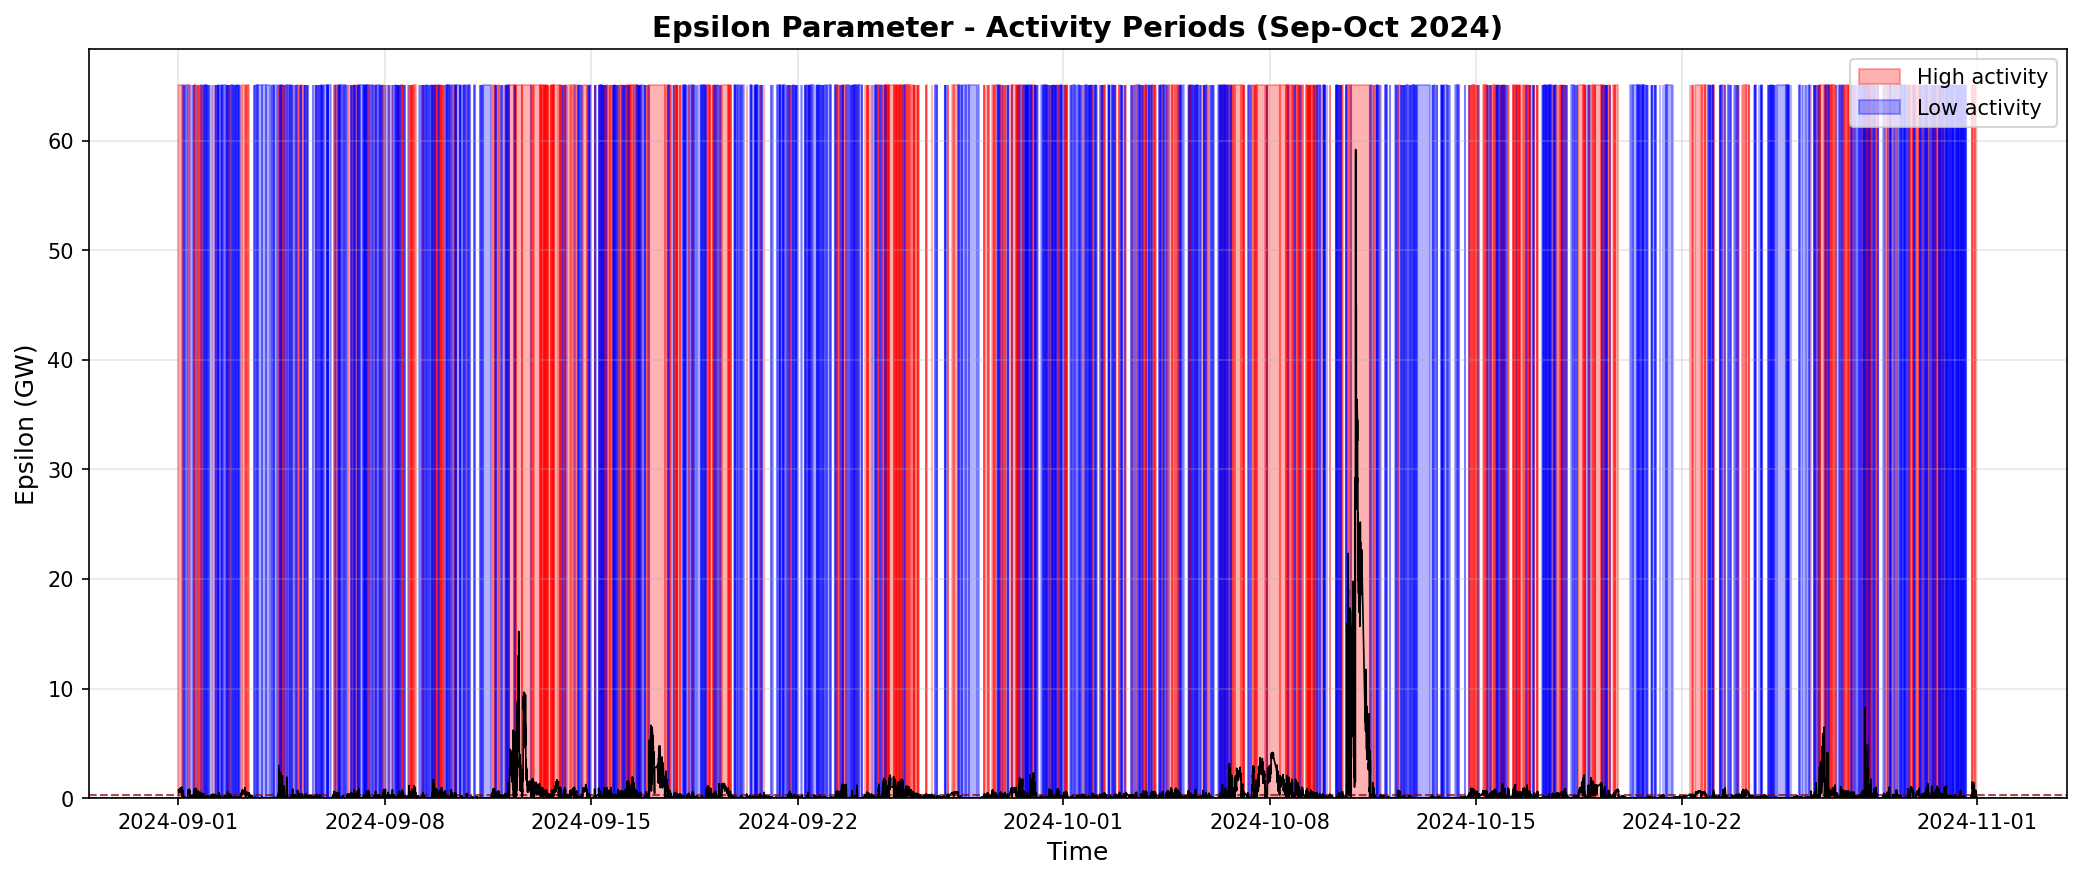

In [38]:
# Define thresholds
epsilon_high = df_filtered['epsilon_GW'].quantile(0.75)
epsilon_low = df_filtered['epsilon_GW'].quantile(0.25)

# Create figure
fig, ax = plt.subplots(1, 1, figsize=(14, 6))

# Plot the main line
ax.plot(df_filtered['time'], df_filtered['epsilon_GW'], linewidth=0.8, color='black', zorder=3)

# Highlight high activity regions (red background)
ax.fill_between(df_filtered['time'], 0, df_filtered['epsilon_GW'].max() * 1.1,
                where=df_filtered['epsilon_GW'] >= epsilon_high,
                alpha=0.3, color='red', label='High activity', zorder=1)

# Highlight low activity regions (blue background)
ax.fill_between(df_filtered['time'], 0, df_filtered['epsilon_GW'].max() * 1.1,
                where=df_filtered['epsilon_GW'] <= epsilon_low,
                alpha=0.3, color='blue', label='Low activity', zorder=1)

# Add threshold lines
ax.axhline(y=epsilon_high, color='darkred', linestyle='--', linewidth=1, alpha=0.7)
ax.axhline(y=epsilon_low, color='darkblue', linestyle='--', linewidth=1, alpha=0.7)

# Labels and styling
ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('Epsilon (GW)', fontsize=12)
ax.set_title('Epsilon Parameter - Activity Periods (Sep-Oct 2024)', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3, zorder=0)
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig('/users/framunno/visual_res/epsilon_activity_periods.png', dpi=150, bbox_inches='tight')
plt.close()

Image.open("/users/framunno/visual_res/epsilon_activity_periods.png")

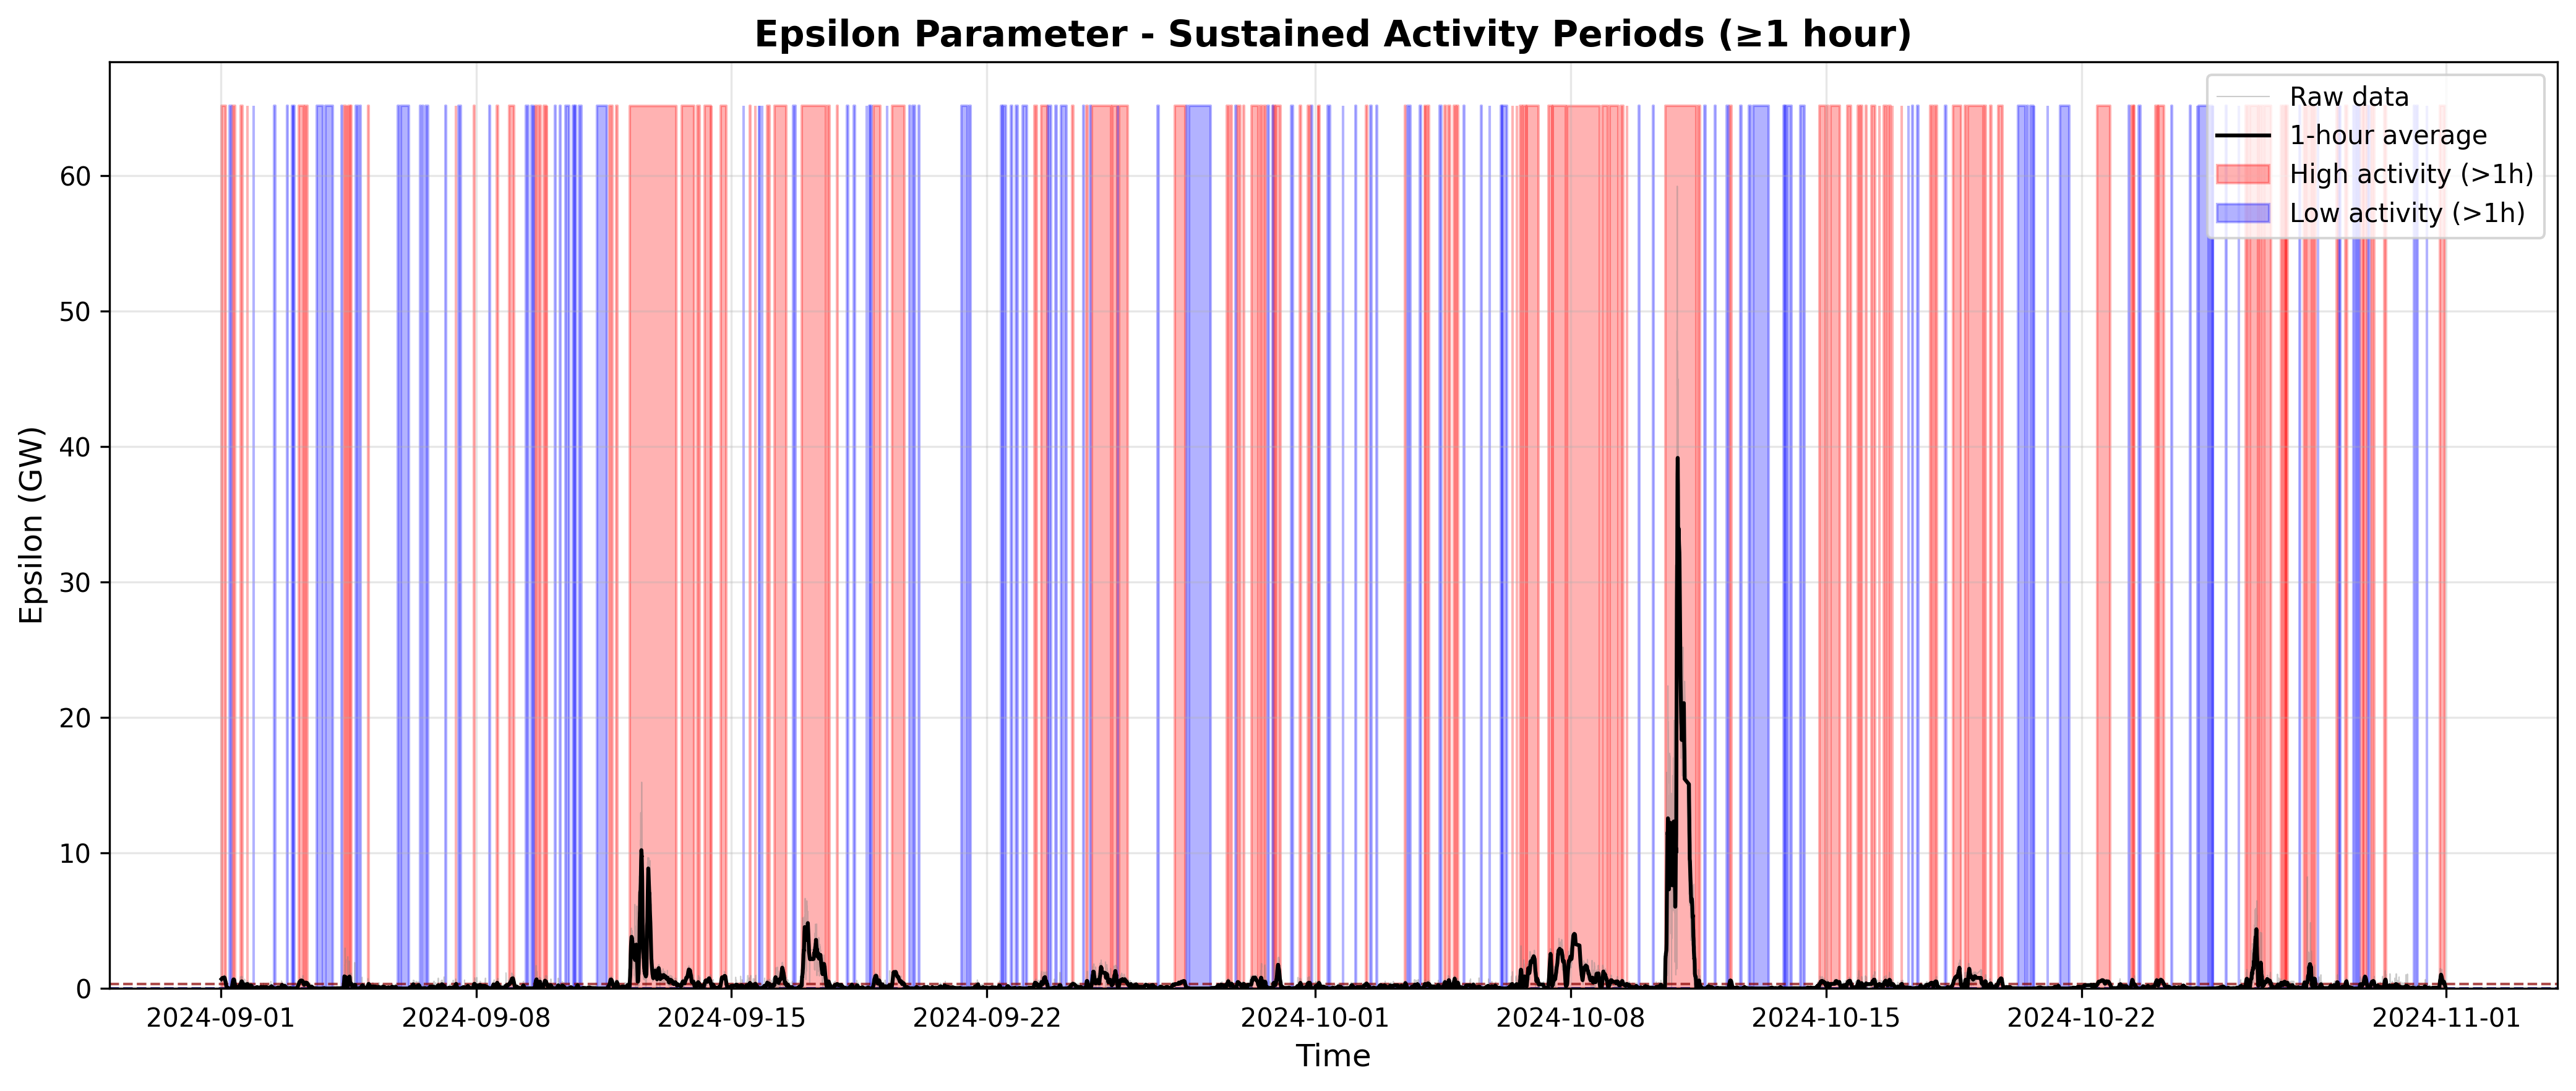

In [40]:
# Define thresholds
epsilon_high = df_filtered['epsilon_GW'].quantile(0.75)
epsilon_low = df_filtered['epsilon_GW'].quantile(0.25)

# Calculate 1-hour rolling average (assuming data is in 5-min intervals, 12 points = 1 hour)
# Adjust window size based on your actual data frequency
time_diff = df_filtered['time'].diff().median()
window_size = int(pd.Timedelta('1 hour') / time_diff)

df_filtered['epsilon_1h_avg'] = df_filtered['epsilon_GW'].rolling(window=window_size, center=True).mean()

# Identify sustained high/low activity periods (at least 1 hour)
df_filtered['is_high'] = df_filtered['epsilon_1h_avg'] >= epsilon_high
df_filtered['is_low'] = df_filtered['epsilon_1h_avg'] <= epsilon_low

# Create figure
fig, ax = plt.subplots(1, 1, figsize=(14, 6))

# Plot original data (thin, semi-transparent)
ax.plot(df_filtered['time'], df_filtered['epsilon_GW'], linewidth=0.5,
        color='gray', alpha=0.4, label='Raw data', zorder=2)

# Plot 1-hour average (main line)
ax.plot(df_filtered['time'], df_filtered['epsilon_1h_avg'], linewidth=1.5,
        color='black', label='1-hour average', zorder=3)

# Highlight sustained high activity regions
ax.fill_between(df_filtered['time'], 0, df_filtered['epsilon_GW'].max() * 1.1,
                where=df_filtered['is_high'],
                alpha=0.3, color='red', label='High activity (>1h)', zorder=1)

# Highlight sustained low activity regions
ax.fill_between(df_filtered['time'], 0, df_filtered['epsilon_GW'].max() * 1.1,
                where=df_filtered['is_low'],
                alpha=0.3, color='blue', label='Low activity (>1h)', zorder=1)

# Add threshold lines
ax.axhline(y=epsilon_high, color='darkred', linestyle='--', linewidth=1, alpha=0.7)
ax.axhline(y=epsilon_low, color='darkblue', linestyle='--', linewidth=1, alpha=0.7)

# Labels and styling
ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('Epsilon (GW)', fontsize=12)
ax.set_title('Epsilon Parameter - Sustained Activity Periods (≥1 hour)', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3, zorder=0)
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig('/users/framunno/visual_res/epsilon_sustained_activity.png', dpi=300, bbox_inches='tight')
plt.close()

Image.open("/users/framunno/visual_res/epsilon_sustained_activity.png")

Loading dataset to extract complete sequence timestamps...
Building L1 conditions cache for valid split...
Cached L1 conditions for 240154 files
Filtered sequences for valid: 1302 -> 698 (53.6% complete)

FILTERING BY HIGH ACTIVITY

Epsilon statistics for 698 sequences:
  Mean:   0.5 GW
  Median: 0.1 GW
  Min:    0.0 GW
  Max:    29.2 GW

Activity thresholds:
  Low activity:      epsilon < 0.0 GW  (< 25th percentile)
  Moderate activity: 0.0 GW ≤ epsilon < 0.3 GW
  High activity:     epsilon ≥ 0.3 GW  (≥ 75th percentile)

Sequence distribution:
  High activity:      175 sequences ( 25.1%)
  Moderate activity:  348 sequences ( 49.9%)
  Low activity:       175 sequences ( 25.1%)

Filtered to high activity: 175 sequences

IonoSequenceIterableDataset [valid]: 175 sequences
  GPU rank: 0/1, Shuffle: True
Found 175 complete sequences in validation split

=== OVERLAP STATISTICS ===
Total complete sequences: 175
  - High activity: 116 (66.3%)
  - Low activity: 2 (1.1%)
  - Moderate activity: 5

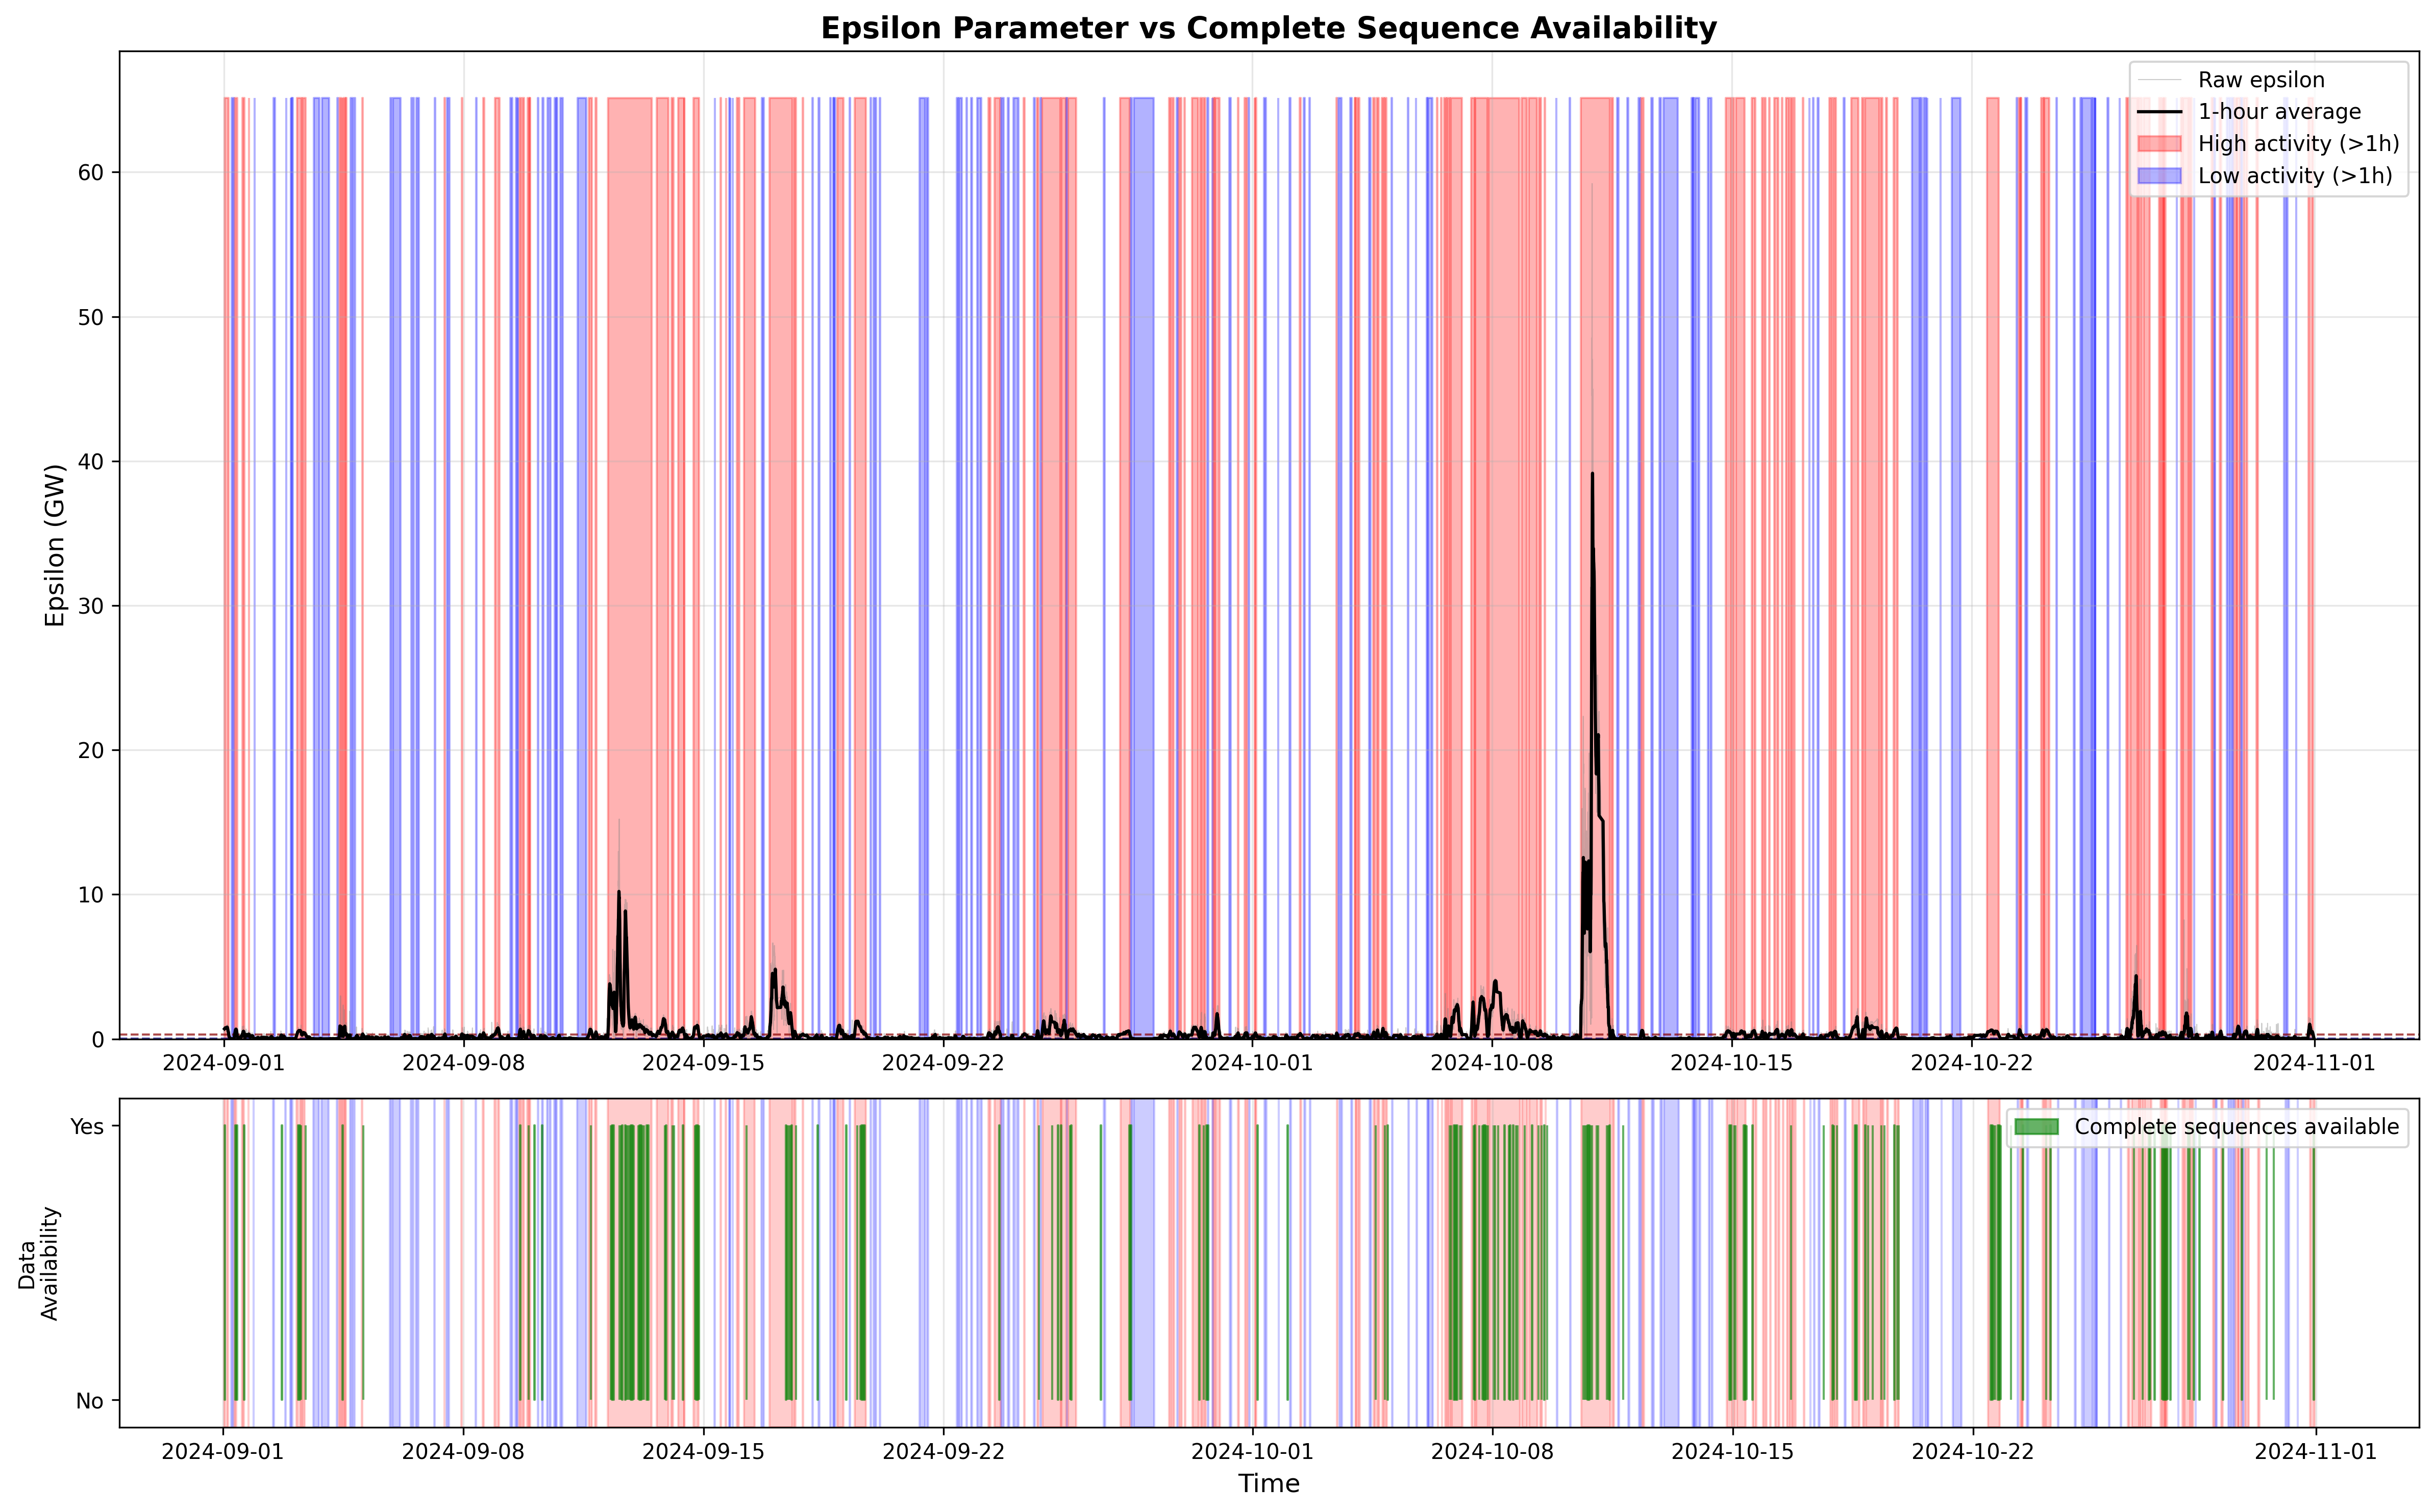

In [41]:
import sys
sys.path.append('/users/framunno/projects/ionosphere_diffusion/src')
from data.dataset import IonoSequenceIterableDataset
from datetime import datetime, timedelta
import pandas as pd

# ============= LOAD YOUR DATASET TO GET COMPLETE SEQUENCES =============
print("Loading dataset to extract complete sequence timestamps...")

# Initialize dataset with only_complete_sequences=True (matching generate_data_v3.py)
dataset = IonoSequenceIterableDataset(
    csv_path='/users/framunno/data/ionosphere/l1_to_map_matched_even_minutes_test_v3_deduplicated.csv',
    sequence_length=30,  # Updated to match generation config
    split='valid',  # September-October data
    only_complete_sequences=True,
    use_l1_conditions=True,
    transforms=False,
    activity_filter='high',  # Only sequences with epsilon ≥ 75th percentile
    min_center_distance=30,
    seed=42,
    epsilon_high_quantile=0.75
)


# Extract timestamps of complete sequences
complete_sequence_times = []
for center_idx in dataset.sequences:
    timestamp = dataset.all_timestamps[center_idx]
    complete_sequence_times.append(timestamp)

print(f"Found {len(complete_sequence_times)} complete sequences in validation split")

# Convert to DataFrame for easier manipulation
df_sequences = pd.DataFrame({'time': complete_sequence_times})
df_sequences = df_sequences.sort_values('time').reset_index(drop=True)

# ============= CALCULATE ACTIVITY PERIODS (from before) =============
epsilon_high = df_filtered['epsilon_GW'].quantile(0.75)
epsilon_low = df_filtered['epsilon_GW'].quantile(0.25)

# Calculate 1-hour rolling average
time_diff = df_filtered['time'].diff().median()
window_size = int(pd.Timedelta('1 hour') / time_diff)
df_filtered['epsilon_1h_avg'] = df_filtered['epsilon_GW'].rolling(window=window_size, center=True).mean()

df_filtered['is_high'] = df_filtered['epsilon_1h_avg'] >= epsilon_high
df_filtered['is_low'] = df_filtered['epsilon_1h_avg'] <= epsilon_low

# ============= CREATE VISUALIZATION WITH OVERLAP =============
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), height_ratios=[3, 1])

# --- Top plot: Epsilon with activity regions ---
ax1.plot(df_filtered['time'], df_filtered['epsilon_GW'], linewidth=0.5,
        color='gray', alpha=0.4, label='Raw epsilon', zorder=2)
ax1.plot(df_filtered['time'], df_filtered['epsilon_1h_avg'], linewidth=1.5,
        color='black', label='1-hour average', zorder=3)

# Highlight activity regions
ax1.fill_between(df_filtered['time'], 0, df_filtered['epsilon_GW'].max() * 1.1,
                where=df_filtered['is_high'],
                alpha=0.3, color='red', label='High activity (>1h)', zorder=1)
ax1.fill_between(df_filtered['time'], 0, df_filtered['epsilon_GW'].max() * 1.1,
                where=df_filtered['is_low'],
                alpha=0.3, color='blue', label='Low activity (>1h)', zorder=1)

# Add threshold lines
ax1.axhline(y=epsilon_high, color='darkred', linestyle='--', linewidth=1, alpha=0.7)
ax1.axhline(y=epsilon_low, color='darkblue', linestyle='--', linewidth=1, alpha=0.7)

ax1.set_ylabel('Epsilon (GW)', fontsize=12)
ax1.set_title('Epsilon Parameter vs Complete Sequence Availability', fontsize=14, fontweight='bold')
ax1.legend(loc='upper right', fontsize=10)
ax1.grid(True, alpha=0.3, zorder=0)
ax1.set_ylim(bottom=0)

# --- Bottom plot: Complete sequence availability ---
# FIX: Ensure timezone compatibility
# Check if df_filtered['time'] is timezone-aware
if df_filtered['time'].dt.tz is not None:
    # Convert complete_sequence_times to timezone-aware (UTC) to match df_filtered
    complete_sequence_times_tz = [pd.Timestamp(t).tz_localize('UTC') for t in complete_sequence_times]
else:
    # Keep as timezone-naive
    complete_sequence_times_tz = complete_sequence_times

# Create a binary availability signal
time_range = pd.date_range(start=df_filtered['time'].min(),
                            end=df_filtered['time'].max(),
                            freq='2min')  # Assuming 2-min resolution
availability = pd.DataFrame({'time': time_range, 'has_sequence': 0})

# Mark times where complete sequences exist
for seq_time in complete_sequence_times_tz:
    # Mark a ±5 minute window around each sequence center
    mask = (availability['time'] >= seq_time - timedelta(minutes=5)) & \
            (availability['time'] <= seq_time + timedelta(minutes=5))
    availability.loc[mask, 'has_sequence'] = 1

ax2.fill_between(availability['time'], 0, 1,
                where=availability['has_sequence'] == 1,
                alpha=0.6, color='green', label='Complete sequences available')
ax2.set_ylabel('Data\nAvailability', fontsize=10)
ax2.set_xlabel('Time', fontsize=12)
ax2.set_ylim(-0.1, 1.1)
ax2.set_yticks([0, 1])
ax2.set_yticklabels(['No', 'Yes'])
ax2.legend(loc='upper right', fontsize=10)
ax2.grid(True, alpha=0.3, axis='x')

# Highlight activity regions in bottom plot too
ax2.fill_between(df_filtered['time'], -0.1, 1.1,
                where=df_filtered['is_high'],
                alpha=0.2, color='red', zorder=0)
ax2.fill_between(df_filtered['time'], -0.1, 1.1,
                where=df_filtered['is_low'],
                alpha=0.2, color='blue', zorder=0)

plt.tight_layout()
plt.savefig('/users/framunno/visual_res/sequence_activity_overlap.png', dpi=300, bbox_inches='tight')
plt.close()

# ============= CALCULATE OVERLAP STATISTICS =============
print("\n=== OVERLAP STATISTICS ===")

# Merge datasets - also fix timezone here
df_sequences_tz = df_sequences.copy()
if df_filtered['time'].dt.tz is not None:
    df_sequences_tz['time'] = pd.to_datetime(df_sequences_tz['time']).dt.tz_localize('UTC')

df_merged = pd.merge_asof(
    df_sequences_tz.sort_values('time'),
    df_filtered[['time', 'is_high', 'is_low', 'epsilon_1h_avg']].sort_values('time'),
    on='time',
    direction='nearest',
    tolerance=pd.Timedelta('5 minutes')
)

total_sequences = len(df_merged)
high_activity_seqs = df_merged['is_high'].sum()
low_activity_seqs = df_merged['is_low'].sum()
moderate_seqs = total_sequences - high_activity_seqs - low_activity_seqs

print(f"Total complete sequences: {total_sequences}")
print(f"  - High activity: {high_activity_seqs} ({high_activity_seqs/total_sequences*100:.1f}%)")
print(f"  - Low activity: {low_activity_seqs} ({low_activity_seqs/total_sequences*100:.1f}%)")
print(f"  - Moderate activity: {moderate_seqs} ({moderate_seqs/total_sequences*100:.1f}%)")

# Show epsilon distribution for complete sequences
print(f"\nEpsilon stats for complete sequences:")
print(f"  Mean: {df_merged['epsilon_1h_avg'].mean():.1f} GW")
print(f"  Median: {df_merged['epsilon_1h_avg'].median():.1f} GW")
print(f"  Min: {df_merged['epsilon_1h_avg'].min():.1f} GW")
print(f"  Max: {df_merged['epsilon_1h_avg'].max():.1f} GW")

Image.open("/users/framunno/visual_res/sequence_activity_overlap.png")

Loading dataset to extract complete sequence timestamps...
Loading train split...
Building L1 conditions cache for train split...
Cached L1 conditions for 240154 files
Filtered sequences for train: 5422 -> 3025 (55.8% complete)

FILTERING BY HIGH ACTIVITY

Epsilon statistics for 3025 sequences:
  Mean:   0.3 GW
  Median: 0.1 GW
  Min:    0.0 GW
  Max:    57.3 GW

Activity thresholds:
  Low activity:      epsilon < 0.0 GW  (< 25th percentile)
  Moderate activity: 0.0 GW ≤ epsilon < 0.2 GW
  High activity:     epsilon ≥ 0.2 GW  (≥ 75th percentile)

Sequence distribution:
  High activity:      757 sequences ( 25.0%)
  Moderate activity: 1511 sequences ( 50.0%)
  Low activity:       757 sequences ( 25.0%)

Filtered to high activity: 757 sequences

IonoSequenceIterableDataset [train]: 757 sequences
  GPU rank: 0/1, Shuffle: True
Loading valid split...
Building L1 conditions cache for valid split...
Cached L1 conditions for 240154 files
Filtered sequences for valid: 1302 -> 698 (53.6% comple

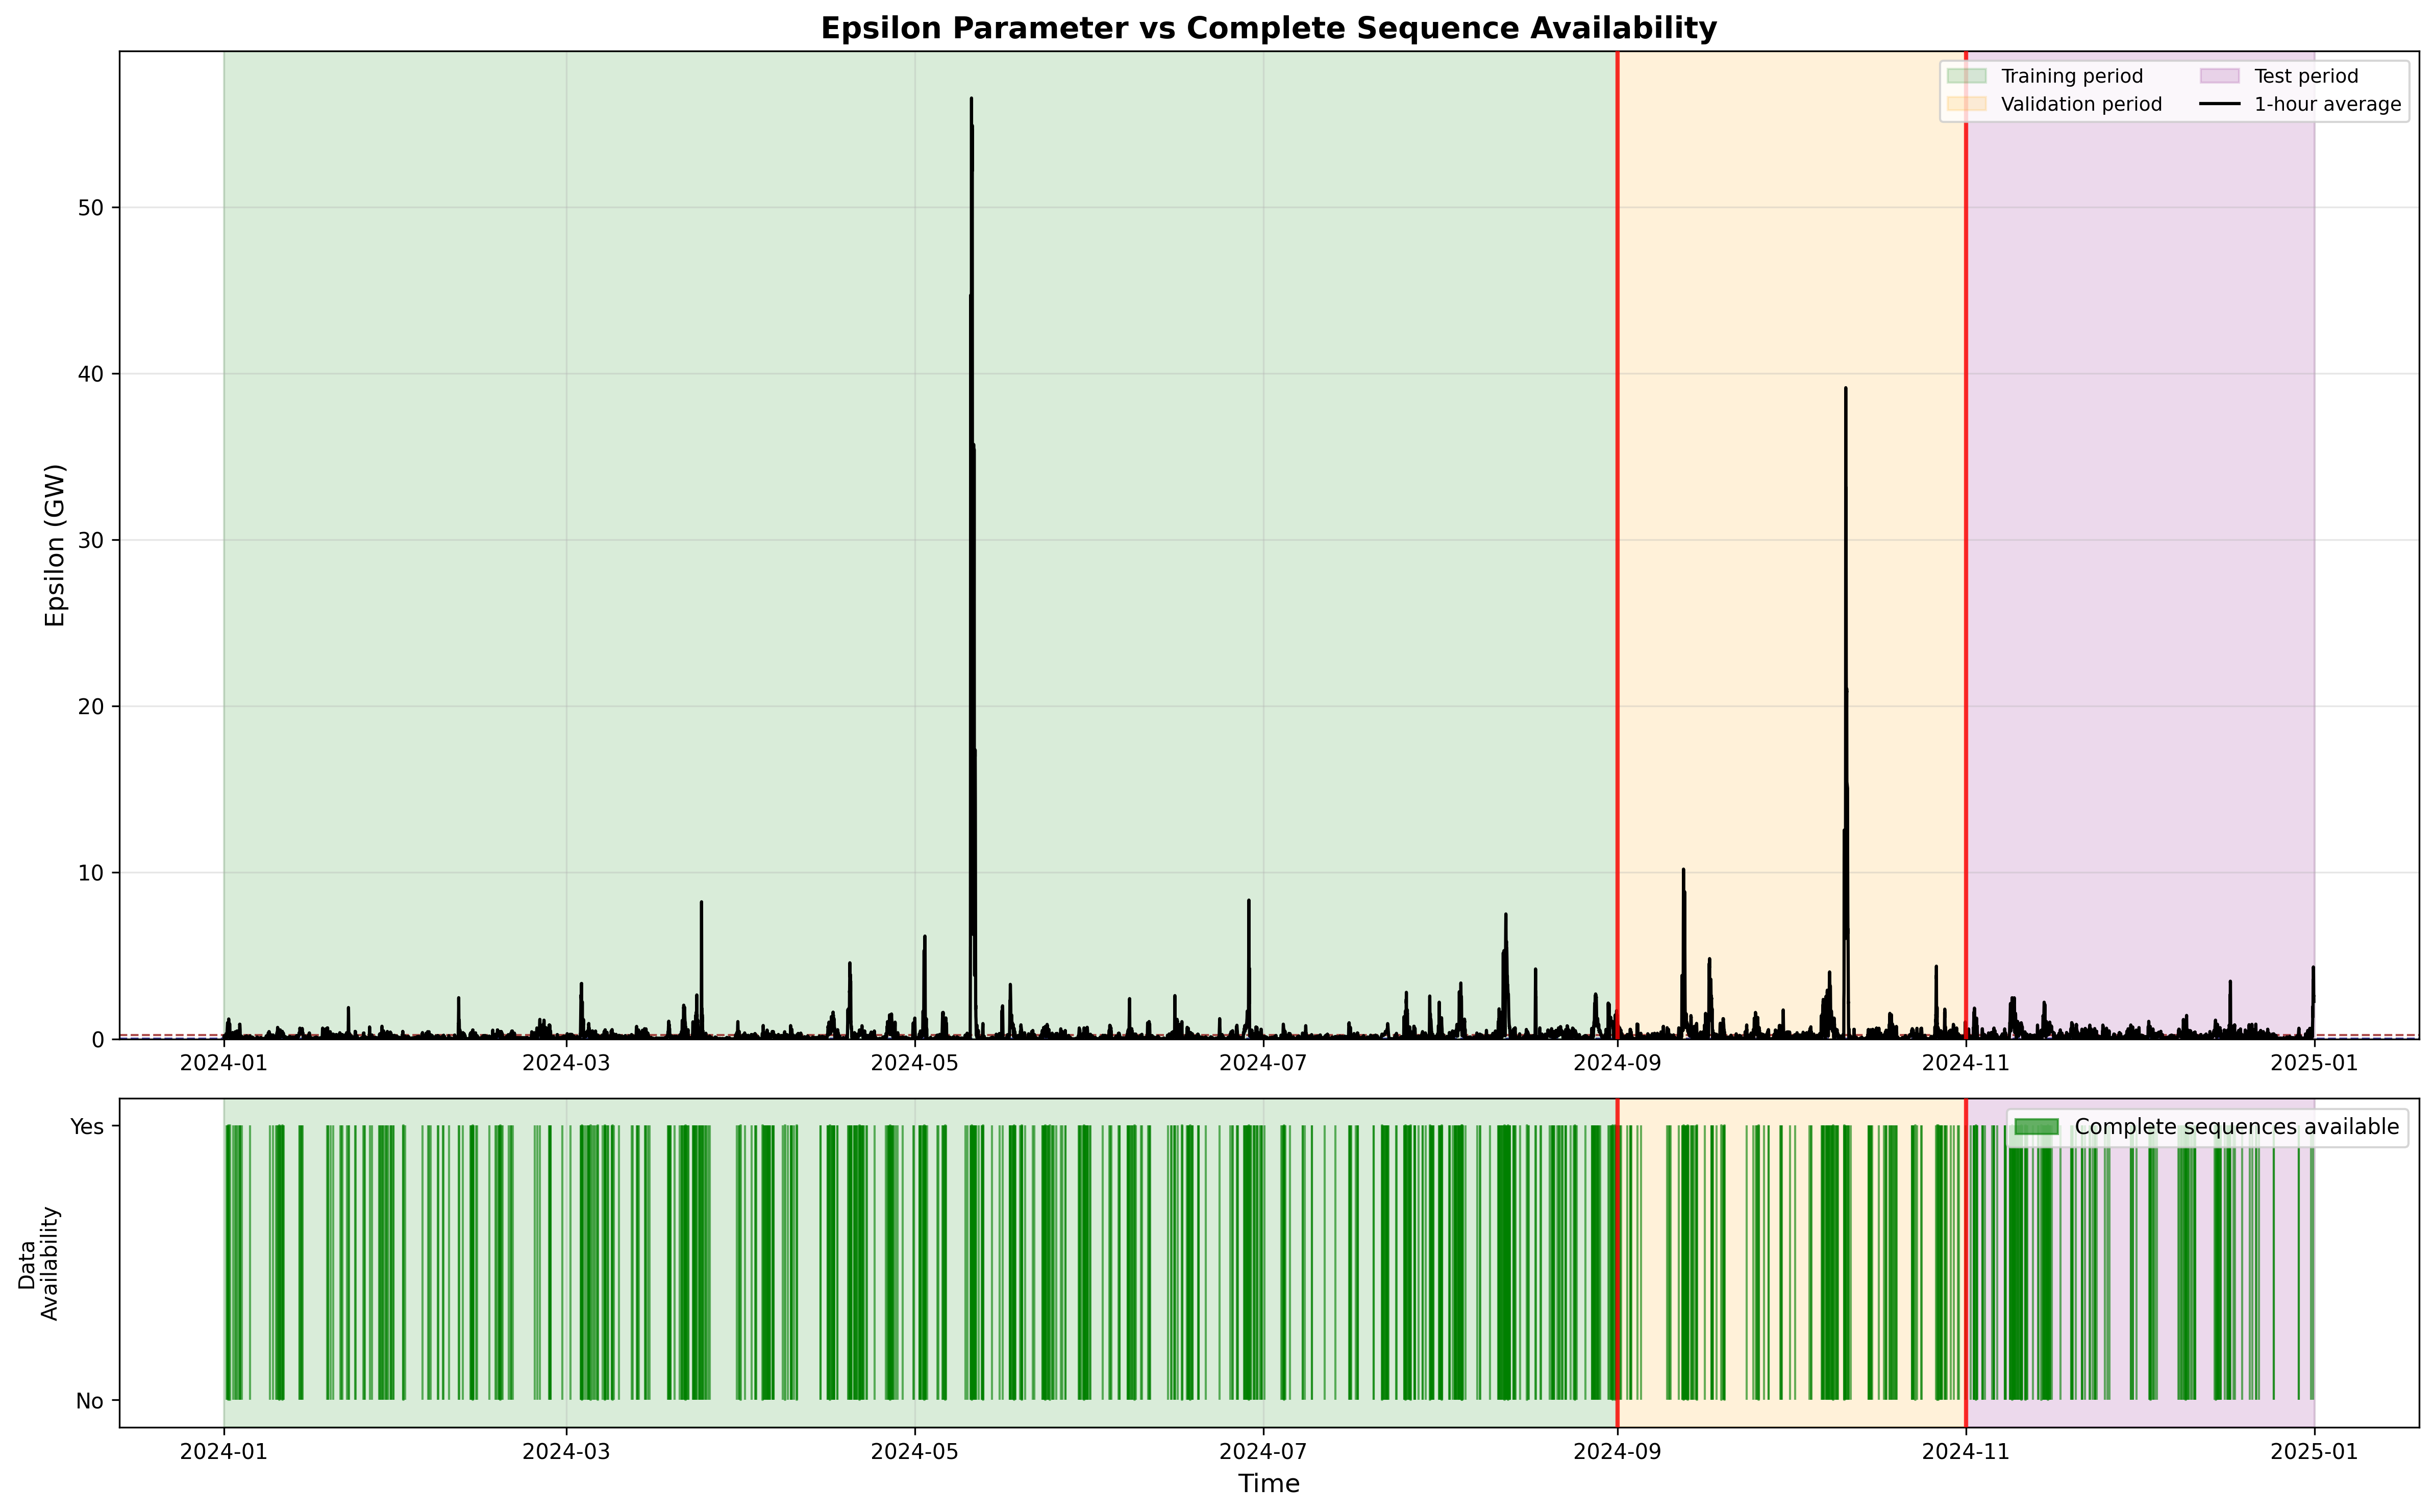

In [32]:
import sys
sys.path.append('/users/framunno/projects/ionosphere_diffusion/src')
from data.dataset import IonoSequenceIterableDataset
from datetime import datetime, timedelta
import pandas as pd

# ============= LOAD YOUR DATASET TO GET COMPLETE SEQUENCES =============
print("Loading dataset to extract complete sequence timestamps...")

# Load all three splits
splits_to_load = ['train', 'valid', 'test']
complete_sequence_times = []

for split_name in splits_to_load:
    print(f"Loading {split_name} split...")
    dataset = IonoSequenceIterableDataset(
        csv_path='/users/framunno/data/ionosphere/l1_to_map_matched_even_minutes_test_v3_deduplicated.csv',
        sequence_length=30,
        split=split_name,
        only_complete_sequences=True,
        use_l1_conditions=True,
        transforms=False,
        activity_filter='high',
        min_center_distance=30,
        seed=42,
        epsilon_high_quantile=0.75
    )

    # Extract timestamps for this split
    for center_idx in dataset.sequences:
        timestamp = dataset.all_timestamps[center_idx]
        complete_sequence_times.append(timestamp)

print(f"Found {len(complete_sequence_times)} complete sequences across all splits")

# Convert to DataFrame for easier manipulation
df_sequences = pd.DataFrame({'time': complete_sequence_times})
df_sequences = df_sequences.sort_values('time').reset_index(drop=True)

# ============= CALCULATE ACTIVITY PERIODS (from before) =============
epsilon_high = df_filtered['epsilon_GW'].quantile(0.75)
epsilon_low = df_filtered['epsilon_GW'].quantile(0.25)

# Calculate 1-hour rolling average
time_diff = df_filtered['time'].diff().median()
window_size = int(pd.Timedelta('1 hour') / time_diff)
df_filtered['epsilon_1h_avg'] = df_filtered['epsilon_GW'].rolling(window=window_size, center=True).mean()

df_filtered['is_high'] = df_filtered['epsilon_1h_avg'] >= epsilon_high
df_filtered['is_low'] = df_filtered['epsilon_1h_avg'] <= epsilon_low

# ============= DEFINE SPLIT PERIODS =============
# Define the date ranges for each split
train_start = pd.Timestamp('2024-01-01', tz='UTC')
train_end = pd.Timestamp('2024-08-31 23:59:59', tz='UTC')
valid_start = pd.Timestamp('2024-09-01', tz='UTC')
valid_end = pd.Timestamp('2024-10-31 23:59:59', tz='UTC')
test_start = pd.Timestamp('2024-11-01', tz='UTC')
test_end = pd.Timestamp('2024-12-31 23:59:59', tz='UTC')

# ============= CREATE VISUALIZATION WITH OVERLAP =============
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), height_ratios=[3, 1])

# --- ADD SPLIT PERIOD BACKGROUNDS (zorder=0 to be behind everything) ---
ax1.axvspan(train_start, train_end, alpha=0.15, color='green', zorder=0, label='Training period')
ax1.axvspan(valid_start, valid_end, alpha=0.15, color='orange', zorder=0, label='Validation period')
ax1.axvspan(test_start, test_end, alpha=0.15, color='purple', zorder=0, label='Test period')

# --- ADD BOLD VERTICAL RED LINES TO SEPARATE PERIODS ---
# ax1.axvline(x=train_start, color='red', linewidth=2, linestyle='-', alpha=0.8, zorder=4)
ax1.axvline(x=valid_start, color='red', linewidth=2, linestyle='-', alpha=0.8, zorder=4)
ax1.axvline(x=test_start, color='red', linewidth=2, linestyle='-', alpha=0.8, zorder=4)
# ax1.axvline(x=test_end, color='red', linewidth=2, linestyle='-', alpha=0.8, zorder=4)

# --- Top plot: Epsilon with activity regions ---
# ax1.plot(df_filtered['time'], df_filtered['epsilon_GW'], linewidth=0.5,
#         color='gray', alpha=0.4, label='Raw epsilon', zorder=2)
ax1.plot(df_filtered['time'], df_filtered['epsilon_1h_avg'], linewidth=1.5,
        color='black', label='1-hour average', zorder=3)

# Highlight activity regions
# ax1.fill_between(df_filtered['time'], 0, df_filtered['epsilon_GW'].max() * 1.1,
#                 where=df_filtered['is_high'],
#                 alpha=0.3, color='red', label='High activity (>1h)', zorder=1)
# ax1.fill_between(df_filtered['time'], 0, df_filtered['epsilon_GW'].max() * 1.1,
#                 where=df_filtered['is_low'],
#                 alpha=0.3, color='blue', label='Low activity (>1h)', zorder=1)

# Add threshold lines
ax1.axhline(y=epsilon_high, color='darkred', linestyle='--', linewidth=1, alpha=0.7)
ax1.axhline(y=epsilon_low, color='darkblue', linestyle='--', linewidth=1, alpha=0.7)

ax1.set_ylabel('Epsilon (GW)', fontsize=12)
ax1.set_title('Epsilon Parameter vs Complete Sequence Availability', fontsize=14, fontweight='bold')
ax1.legend(loc='upper right', fontsize=9, ncol=2)  # 2 columns to fit all labels
ax1.grid(True, alpha=0.3, zorder=0)
ax1.set_ylim(bottom=0)

# --- Bottom plot: Complete sequence availability ---
# ADD SPLIT PERIOD BACKGROUNDS to bottom plot too
ax2.axvspan(train_start, train_end, alpha=0.15, color='green', zorder=0)
ax2.axvspan(valid_start, valid_end, alpha=0.15, color='orange', zorder=0)
ax2.axvspan(test_start, test_end, alpha=0.15, color='purple', zorder=0)

# --- ADD BOLD VERTICAL RED LINES TO BOTTOM PLOT TOO ---
# ax2.axvline(x=train_start, color='red', linewidth=2, linestyle='-', alpha=0.8, zorder=4)
ax2.axvline(x=valid_start, color='red', linewidth=2, linestyle='-', alpha=0.8, zorder=4)
ax2.axvline(x=test_start, color='red', linewidth=2, linestyle='-', alpha=0.8, zorder=4)
# ax2.axvline(x=test_end, color='red', linewidth=2, linestyle='-', alpha=0.8, zorder=4)

# FIX: Ensure timezone compatibility
# Check if df_filtered['time'] is timezone-aware
if df_filtered['time'].dt.tz is not None:
    # Convert complete_sequence_times to timezone-aware (UTC) to match df_filtered
    complete_sequence_times_tz = [pd.Timestamp(t).tz_localize('UTC') for t in complete_sequence_times]
else:
    # Keep as timezone-naive
    complete_sequence_times_tz = complete_sequence_times

# Create a binary availability signal
time_range = pd.date_range(start=df_filtered['time'].min(),
                            end=df_filtered['time'].max(),
                            freq='2min')  # Assuming 2-min resolution
availability = pd.DataFrame({'time': time_range, 'has_sequence': 0})

# Mark times where complete sequences exist
for seq_time in complete_sequence_times_tz:
    # Mark a ±5 minute window around each sequence center
    mask = (availability['time'] >= seq_time - timedelta(minutes=5)) & \
            (availability['time'] <= seq_time + timedelta(minutes=5))
    availability.loc[mask, 'has_sequence'] = 1

ax2.fill_between(availability['time'], 0, 1,
                where=availability['has_sequence'] == 1,
                alpha=0.6, color='green', label='Complete sequences available', zorder=2)
ax2.set_ylabel('Data\nAvailability', fontsize=10)
ax2.set_xlabel('Time', fontsize=12)
ax2.set_ylim(-0.1, 1.1)
ax2.set_yticks([0, 1])
ax2.set_yticklabels(['No', 'Yes'])
ax2.legend(loc='upper right', fontsize=10)
ax2.grid(True, alpha=0.3, axis='x')

# Highlight activity regions in bottom plot too
# ax2.fill_between(df_filtered['time'], -0.1, 1.1,
#                 where=df_filtered['is_high'],
#                 alpha=0.2, color='red', zorder=1)
# ax2.fill_between(df_filtered['time'], -0.1, 1.1,
#                 where=df_filtered['is_low'],
#                 alpha=0.2, color='blue', zorder=1)

plt.tight_layout()
plt.savefig('/users/framunno/visual_res/sequence_activity_overlap.png', dpi=300, bbox_inches='tight')
plt.close()

# ============= CALCULATE OVERLAP STATISTICS =============
print("\n=== OVERLAP STATISTICS ===")

# Merge datasets - also fix timezone here
df_sequences_tz = df_sequences.copy()
if df_filtered['time'].dt.tz is not None:
    df_sequences_tz['time'] = pd.to_datetime(df_sequences_tz['time']).dt.tz_localize('UTC')

df_merged = pd.merge_asof(
    df_sequences_tz.sort_values('time'),
    df_filtered[['time', 'is_high', 'is_low', 'epsilon_1h_avg']].sort_values('time'),
    on='time',
    direction='nearest',
    tolerance=pd.Timedelta('5 minutes')
)

total_sequences = len(df_merged)
high_activity_seqs = df_merged['is_high'].sum()
low_activity_seqs = df_merged['is_low'].sum()
moderate_seqs = total_sequences - high_activity_seqs - low_activity_seqs

print(f"Total complete sequences: {total_sequences}")
print(f"  - High activity: {high_activity_seqs} ({high_activity_seqs/total_sequences*100:.1f}%)")
print(f"  - Low activity: {low_activity_seqs} ({low_activity_seqs/total_sequences*100:.1f}%)")
print(f"  - Moderate activity: {moderate_seqs} ({moderate_seqs/total_sequences*100:.1f}%)")

# Show epsilon distribution for complete sequences
print(f"\nEpsilon stats for complete sequences:")
print(f"  Mean: {df_merged['epsilon_1h_avg'].mean():.1f} GW")
print(f"  Median: {df_merged['epsilon_1h_avg'].median():.1f} GW")
print(f"  Min: {df_merged['epsilon_1h_avg'].min():.1f} GW")
print(f"  Max: {df_merged['epsilon_1h_avg'].max():.1f} GW")

Image.open("/users/framunno/visual_res/sequence_activity_overlap.png")

In [1]:
# Restart kernel or reload the module
import importlib
import sys
sys.path.append('/users/framunno/projects/ionosphere_diffusion/src')
from data import dataset as dataset_module
importlib.reload(dataset_module)
from data.dataset import IonoSequenceIterableDataset, get_sequence_data_objects_iterable

# Now create the dataloader
dataset, _, dataloader = get_sequence_data_objects_iterable(
    batch_size=2,
    num_data_workers=1,
    sequence_length=30,
    split='valid',
    csv_path='/users/framunno/data/ionosphere/l1_to_map_matched_even_minutes_test_v3_deduplicated.csv',
    use_l1_conditions=True,
    only_complete_sequences=True,
    activity_filter='high',  # Only sequences with epsilon ≥ 75th percentile
    min_center_distance=30,
    seed=42,
    epsilon_high_quantile=0.97
    
)

for data_batch, cond_batch, epsilon_batch in dataloader:
    print(f"Data: {data_batch.shape}")
    print(f"Conditions: {cond_batch.shape}")
    print(f"Epsilon: {epsilon_batch.shape}")
    print(f"Epsilon range: {epsilon_batch.min():.1f} - {epsilon_batch.max():.1f} GW")
    break

Building L1 conditions cache for valid split...
Cached L1 conditions for 240154 files
Filtered sequences for valid: 1302 -> 698 (53.6% complete)

FILTERING BY HIGH ACTIVITY

Epsilon statistics for 698 sequences:
  Mean:   0.5 GW
  Median: 0.1 GW
  Min:    0.0 GW
  Max:    29.2 GW

Activity thresholds:
  Low activity:      epsilon < 0.0 GW  (< 25th percentile)
  Moderate activity: 0.0 GW ≤ epsilon < 2.7 GW
  High activity:     epsilon ≥ 2.7 GW  (≥ 97th percentile)

Sequence distribution:
  High activity:       21 sequences (  3.0%)
  Moderate activity:  502 sequences ( 71.9%)
  Low activity:       175 sequences ( 25.1%)

Filtered to high activity: 21 sequences

IonoSequenceIterableDataset [valid]: 21 sequences
  GPU rank: 0/1, Shuffle: True
Data: torch.Size([2, 30, 1, 24, 360])
Conditions: torch.Size([2, 30, 4])
Epsilon: torch.Size([2, 30, 1])
Epsilon range: 1.7 - 9.4 GW



SEQUENCE-LEVEL ANALYSIS (30 frames per sequence)
Total sequences checked: 34807
Complete sequences: 2880
Failed sequences: 31927

WHAT KILLS SEQUENCES:
  Time gaps (no file at expected time): 31927
  Missing images: 0
  Missing bx_gsm: 0
  Missing by_gsm: 0
  Missing bz_gsm: 0
  Missing proton_vx_gsm: 0


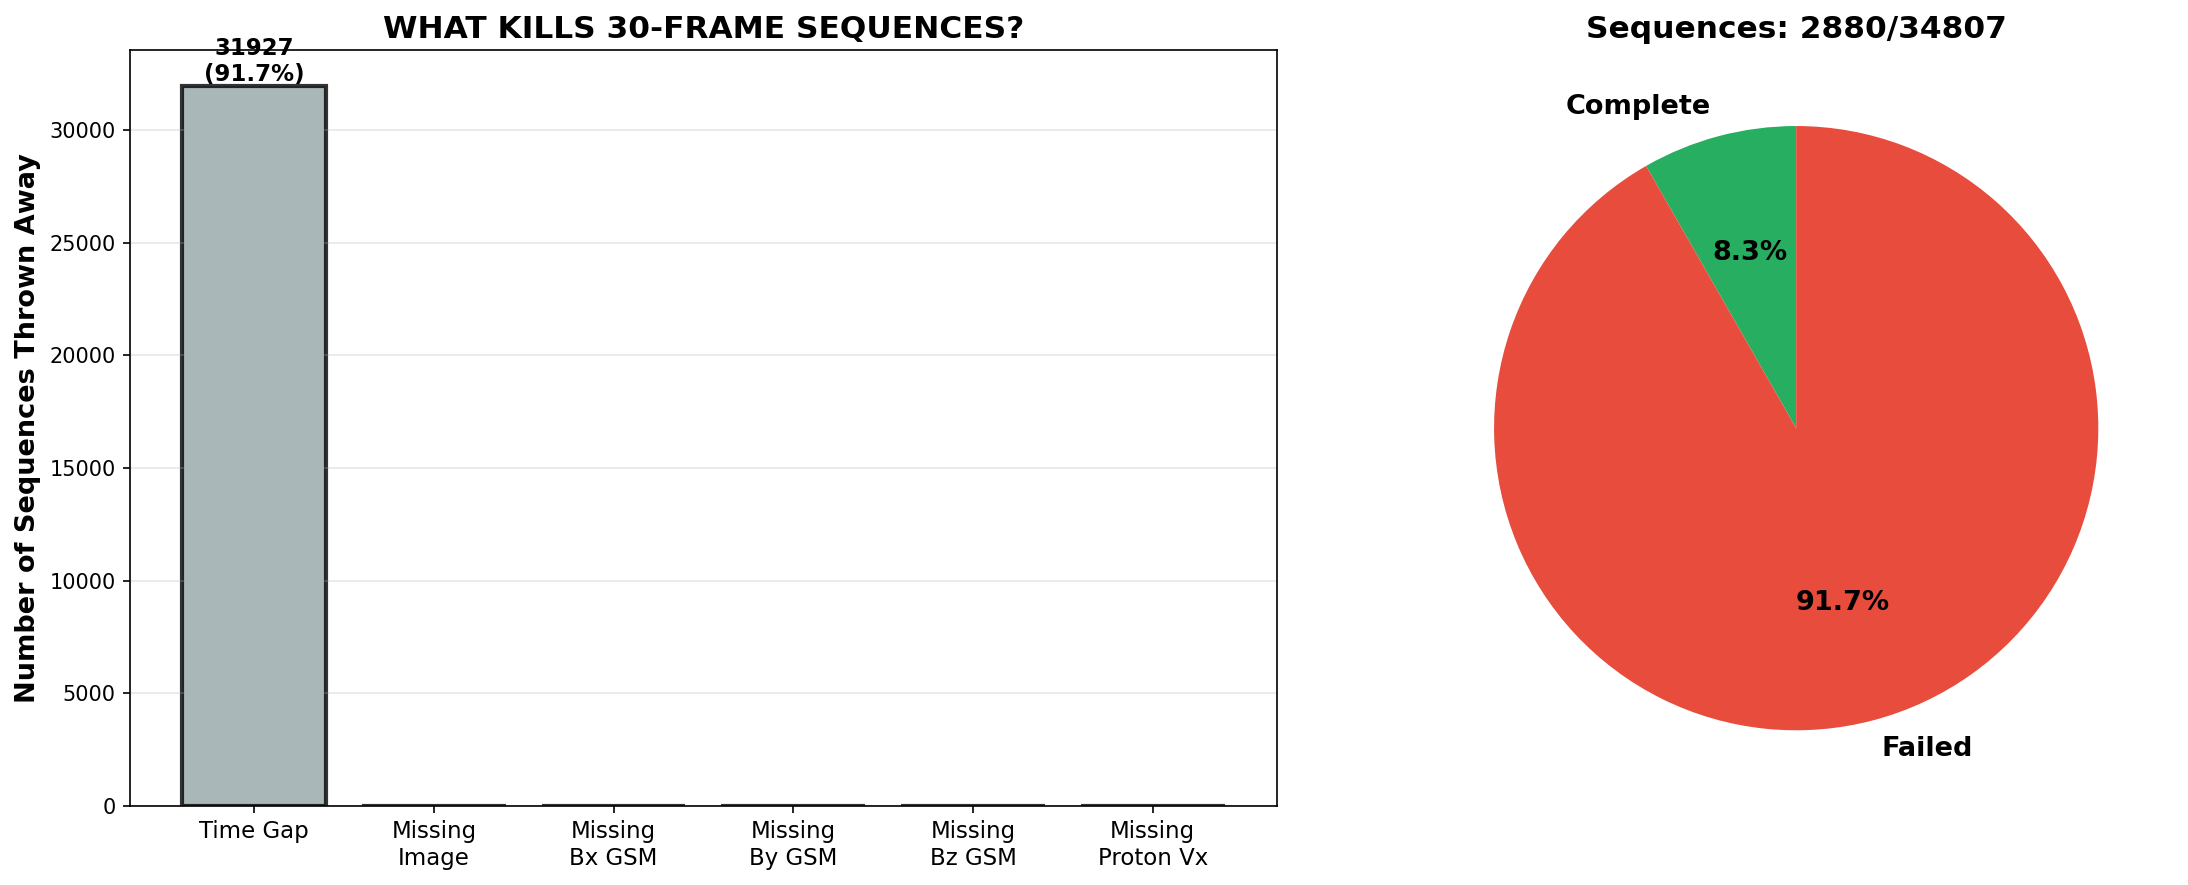

In [ ]:
import sys
sys.path.append('/users/framunno/projects/ionosphere_diffusion/src')
from datetime import datetime, timedelta



WHAT KILLS 30-FRAME SEQUENCES
(Time gaps = missing image + all 4 conditions)
Total sequences: 40281
Complete: 2357
Failed: 37924

Sequences killed by missing:
  IMAGE:         37924
  bx_gsm:        37924
  by_gsm:        37924
  bz_gsm:        37924
  proton_vx_gsm: 37924


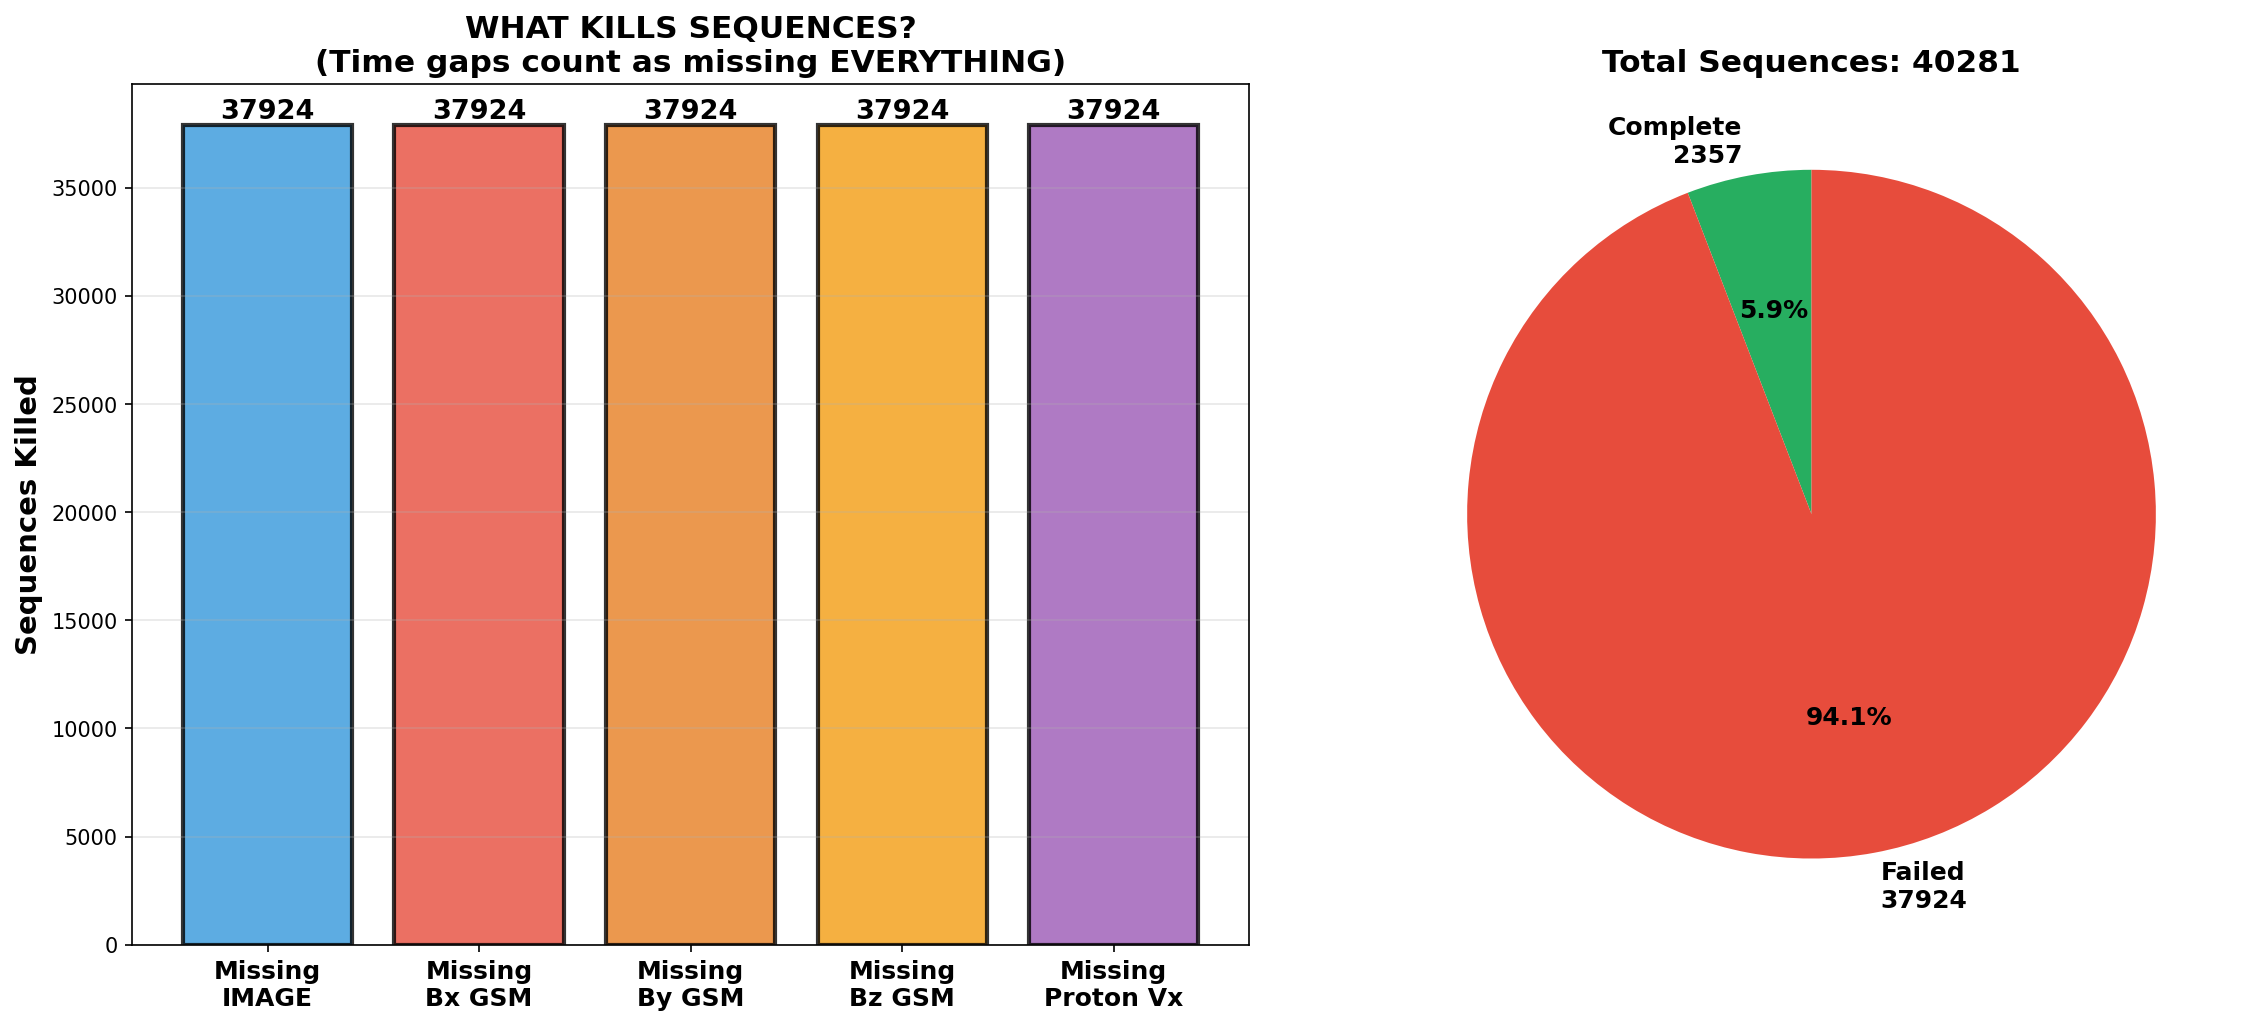

In [31]:
import sys
sys.path.append('/users/framunno/projects/ionosphere_diffusion/src')
from datetime import datetime, timedelta
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use("Agg")
from PIL import Image
import os
from pathlib import Path

def extract_timestamp(filename):
    base = Path(filename).stem
    parts = base.split('_')
    try:
        dt = datetime(int(parts[-6]), int(parts[-5]), int(parts[-4]),
                    int(parts[-3]), int(parts[-2]), int(parts[-1]))
    except:
        dt = None
    return dt

# ============= LOAD =============
IMAGE_DIR = '/users/framunno/data/ionosphere/ionosphere_data/pickled_maps/'
df = pd.read_csv('/users/framunno/data/ionosphere/l1_to_map_matched_even_minutes.csv')
df['timestamp'] = df['filename'].apply(extract_timestamp)
df = df.dropna(subset=['timestamp']).sort_values('timestamp').reset_index(drop=True)
df['month'] = df['timestamp'].dt.month
df = df[df['month'].isin([9, 10])].copy().reset_index(drop=True)

df['image_exists'] = df['filename'].apply(lambda f: os.path.exists(os.path.join(IMAGE_DIR, f)))

l1_cols = ['bx_gsm', 'by_gsm', 'bz_gsm', 'proton_vx_gsm']
for col in l1_cols:
    df[f'{col}_exists'] = ~((df[col] == -99999) | df[col].isna())

# ============= COUNT WHAT'S MISSING IN SEQUENCES =============
sequence_length = 30

# Counters - if time gap, count ALL as missing
missing_counts = {
    'image': 0,
    'bx_gsm': 0,
    'by_gsm': 0,
    'bz_gsm': 0,
    'proton_vx_gsm': 0
}

complete_sequences = 0
total_sequences = 0

n = len(df)
i = 0
while i + sequence_length <= n:
    center_idx = i + sequence_length // 2
    total_sequences += 1

    start_idx = center_idx - sequence_length // 2
    center_time = df.iloc[center_idx]['timestamp']
    expected_start = center_time - timedelta(minutes=2 * (sequence_length // 2))

    sequence_complete = True

    for frame_num in range(sequence_length):
        file_idx = start_idx + frame_num
        expected_time = expected_start + timedelta(minutes=2 * frame_num)
        actual_time = df.iloc[file_idx]['timestamp']

        # Check time gap
        if abs((actual_time - expected_time).total_seconds()) > 60:
            # TIME GAP = everything is missing!
            sequence_complete = False
            missing_counts['image'] += 1
            missing_counts['bx_gsm'] += 1
            missing_counts['by_gsm'] += 1
            missing_counts['bz_gsm'] += 1
            missing_counts['proton_vx_gsm'] += 1
            break  # This sequence is dead

        # File exists at right time, check what's in it
        if not df.iloc[file_idx]['image_exists']:
            sequence_complete = False
            missing_counts['image'] += 1
            break

        if not df.iloc[file_idx]['bx_gsm_exists']:
            sequence_complete = False
            missing_counts['bx_gsm'] += 1
            break

        if not df.iloc[file_idx]['by_gsm_exists']:
            sequence_complete = False
            missing_counts['by_gsm'] += 1
            break

        if not df.iloc[file_idx]['bz_gsm_exists']:
            sequence_complete = False
            missing_counts['bz_gsm'] += 1
            break

        if not df.iloc[file_idx]['proton_vx_gsm_exists']:
            sequence_complete = False
            missing_counts['proton_vx_gsm'] += 1
            break

    if sequence_complete:
        complete_sequences += 1

    i += 1

# ============= VISUALIZE =============
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Plot 1: What's missing
labels = ['Missing\nIMAGE', 'Missing\nBx GSM', 'Missing\nBy GSM',
        'Missing\nBz GSM', 'Missing\nProton Vx']
counts = [
    missing_counts['image'],
    missing_counts['bx_gsm'],
    missing_counts['by_gsm'],
    missing_counts['bz_gsm'],
    missing_counts['proton_vx_gsm']
]
colors = ['#3498db', '#e74c3c', '#e67e22', '#f39c12', '#9b59b6']

bars = ax1.bar(range(len(labels)), counts, color=colors, alpha=0.8, edgecolor='black', linewidth=2)
ax1.set_xticks(range(len(labels)))
ax1.set_xticklabels(labels, fontsize=12, fontweight='bold')
ax1.set_ylabel('Sequences Killed', fontsize=14, fontweight='bold')
ax1.set_title('WHAT KILLS SEQUENCES?\n(Time gaps count as missing EVERYTHING)', fontsize=15, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')

for bar, count, label in zip(bars, counts, labels):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{count}',
            ha='center', va='bottom', fontsize=13, fontweight='bold')

# Plot 2: Pie
failed = total_sequences - complete_sequences
ax2.pie([complete_sequences, failed],
        labels=[f'Complete\n{complete_sequences}', f'Failed\n{failed}'],
        autopct='%1.1f%%',
        colors=['#27ae60', '#e74c3c'],
        startangle=90,
        textprops={'fontsize': 12, 'fontweight': 'bold'})
ax2.set_title(f'Total Sequences: {total_sequences}', fontsize=15, fontweight='bold')

plt.tight_layout()
plt.savefig('/users/framunno/visual_res/WHAT_IS_MISSING_FINAL.png', dpi=150, bbox_inches='tight')
plt.close()

# ============= RESULTS =============
print("\n" + "="*70)
print("WHAT KILLS 30-FRAME SEQUENCES")
print("(Time gaps = missing image + all 4 conditions)")
print("="*70)
print(f"Total sequences: {total_sequences}")
print(f"Complete: {complete_sequences}")
print(f"Failed: {failed}")
print(f"\nSequences killed by missing:")
print(f"  IMAGE:         {missing_counts['image']}")
print(f"  bx_gsm:        {missing_counts['bx_gsm']}")
print(f"  by_gsm:        {missing_counts['by_gsm']}")
print(f"  bz_gsm:        {missing_counts['bz_gsm']}")
print(f"  proton_vx_gsm: {missing_counts['proton_vx_gsm']}")

Image.open("/users/framunno/visual_res/WHAT_IS_MISSING_FINAL.png")

In [20]:
import os
from pathlib import Path
from datetime import datetime, timedelta
import pandas as pd
import numpy as np

# ============= SCAN DIRECTORY =============
IMAGE_DIR = '/users/framunno/data/ionosphere/ionosphere_data/pickled_maps/'

print("Scanning directory for .npy files...")
all_files = [f for f in os.listdir(IMAGE_DIR) if f.endswith('.npy')]

print(f"Total .npy files in directory: {len(all_files)}")

# ============= PARSE FILENAMES =============
def parse_filename(filename):
    """Parse filename like map_2024_9_9_9_50_0.npy or _2024_5_9_9_50_0.npy"""
    base = Path(filename).stem  # Remove .npy
    parts = base.split('_')

    try:
        # Find where the date starts (skip 'map' or empty string)
        if parts[0] == 'map' or parts[0] == '':
            parts = parts[1:]

        year = int(parts[0])
        month = int(parts[1])
        day = int(parts[2])
        hour = int(parts[3])
        minute = int(parts[4])
        second = int(parts[5])

        return datetime(year, month, day, hour, minute, second)
    except:
        return None

# Parse all filenames
file_data = []
for f in all_files:
    ts = parse_filename(f)
    if ts is not None:
        file_data.append({'filename': f, 'timestamp': ts, 'month': ts.month})

df_files = pd.DataFrame(file_data)

print(f"Successfully parsed: {len(df_files)} files")

# ============= FILTER FOR SEPTEMBER & OCTOBER =============
df_sep_oct = df_files[df_files['month'].isin([9, 10])].copy()
df_sep_oct = df_sep_oct.sort_values('timestamp').reset_index(drop=True)

print(f"\nFiles in September-October 2024: {len(df_sep_oct)}")

if len(df_sep_oct) > 0:
    min_time = df_sep_oct['timestamp'].min()
    max_time = df_sep_oct['timestamp'].max()

    print(f"Time range: {min_time} to {max_time}")

    # ============= CALCULATE EXPECTED FILES =============
    total_duration = max_time - min_time
    total_minutes = total_duration.total_seconds() / 60
    total_hours = total_minutes / 60
    total_days = total_hours / 24

    # Expected files: 1 every 2 minutes
    expected_files = int(total_minutes / 2) + 1  # +1 to include both endpoints

    actual_files = len(df_sep_oct)
    missing_files = expected_files - actual_files
    coverage_percent = (actual_files / expected_files) * 100

    print(f"\n" + "="*70)
    print("TEMPORAL COVERAGE ANALYSIS")
    print("="*70)
    print(f"Time span: {total_days:.1f} days ({total_hours:.1f} hours, {total_minutes:.0f} minutes)")
    print(f"\nExpected files (1 every 2 minutes): {expected_files}")
    print(f"Actual files found on disk:          {actual_files}")
    print(f"Missing files:                        {missing_files}")
    print(f"\nTemporal coverage: {coverage_percent:.2f}%")
    print(f"Missing coverage:  {100-coverage_percent:.2f}%")

    # ============= ANALYZE TIME GAPS =============
    df_sep_oct['time_diff'] = df_sep_oct['timestamp'].diff()
    df_sep_oct['gap_minutes'] = df_sep_oct['time_diff'].dt.total_seconds() / 60

    # Count gaps
    gaps = df_sep_oct[df_sep_oct['gap_minutes'] > 2.5]  # More than 2.5 minutes = gap

    print(f"\n" + "="*70)
    print("TIME GAP ANALYSIS")
    print("="*70)
    print(f"Number of time gaps (> 2.5 min): {len(gaps)}")

    if len(gaps) > 0:
        total_gap_time = gaps['gap_minutes'].sum() - (len(gaps) * 2)  # Subtract expected 2 min
        print(f"Total missing time due to gaps: {total_gap_time:.0f} minutes ({total_gap_time/60:.1f} hours)")
        print(f"\nLargest gaps:")

        for i, row in gaps.nlargest(10, 'gap_minutes').iterrows():
            prev_time = df_sep_oct.iloc[i-1]['timestamp']
            curr_time = row['timestamp']
            gap_min = row['gap_minutes']
            missing = int(gap_min / 2) - 1

            print(f"  {prev_time.strftime('%Y-%m-%d %H:%M')} -> {curr_time.strftime('%H:%M')}: "
                f"{gap_min:.0f} min gap ({missing} files missing)")

        # Gap size distribution
        gap_sizes = gaps['gap_minutes'].values
        print(f"\nGap size distribution:")
        print(f"  Small gaps (2-10 min):   {sum((gap_sizes > 2) & (gap_sizes <= 10))} gaps")
        print(f"  Medium gaps (10-60 min): {sum((gap_sizes > 10) & (gap_sizes <= 60))} gaps")
        print(f"  Large gaps (1-6 hours):  {sum((gap_sizes > 60) & (gap_sizes <= 360))} gaps")
        print(f"  Huge gaps (> 6 hours):   {sum(gap_sizes > 360)} gaps")

    # ============= COMPARISON WITH CSV =============
    print(f"\n" + "="*70)
    print("COMPARISON: DIRECTORY vs CSV")
    print("="*70)

    # Load CSV to compare
    df_csv = pd.read_csv('/users/framunno/data/ionosphere/l1_earth_associated_with_maps.csv')
    df_csv['timestamp'] = df_csv['filename'].apply(parse_filename)
    df_csv = df_csv.dropna(subset=['timestamp'])
    df_csv['month'] = df_csv['timestamp'].dt.month
    df_csv_sep_oct = df_csv[df_csv['month'].isin([9, 10])]

    print(f"Files in CSV (Sep-Oct):       {len(df_csv_sep_oct)}")
    print(f"Files on disk (Sep-Oct):      {len(df_sep_oct)}")
    print(f"Difference:                   {abs(len(df_csv_sep_oct) - len(df_sep_oct))}")

    if len(df_csv_sep_oct) == len(df_sep_oct):
        print("\n✓ CSV and disk match perfectly!")
    else:
        print(f"\n✗ Mismatch between CSV and disk")

Scanning directory for .npy files...
Total .npy files in directory: 263152
Successfully parsed: 263152 files

Files in September-October 2024: 43859
Time range: 2024-09-01 00:00:00 to 2024-10-31 23:56:00

TEMPORAL COVERAGE ANALYSIS
Time span: 61.0 days (1463.9 hours, 87836 minutes)

Expected files (1 every 2 minutes): 43919
Actual files found on disk:          43859
Missing files:                        60

Temporal coverage: 99.86%
Missing coverage:  0.14%

TIME GAP ANALYSIS
Number of time gaps (> 2.5 min): 60
Total missing time due to gaps: 120 minutes (2.0 hours)

Largest gaps:
  2024-09-01 23:56 -> 00:00: 4 min gap (1 files missing)
  2024-09-02 23:56 -> 00:00: 4 min gap (1 files missing)
  2024-09-03 23:56 -> 00:00: 4 min gap (1 files missing)
  2024-09-04 23:56 -> 00:00: 4 min gap (1 files missing)
  2024-09-05 23:56 -> 00:00: 4 min gap (1 files missing)
  2024-09-06 23:56 -> 00:00: 4 min gap (1 files missing)
  2024-09-07 23:56 -> 00:00: 4 min gap (1 files missing)
  2024-09-08 

In [2]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

print("="*80)
print("SOLAR WIND CONDITIONING DATA ANALYSIS")
print("="*80)

# Load the solar wind data
print("\nLoading solar wind data...")
df = pd.read_csv('/users/framunno/data/ionosphere/combined_f1m_m1m_2024.csv')
print(f"Total records loaded: {len(df):,}")

# Parse time column
print("Parsing timestamps...")
df['time'] = pd.to_datetime(df['time'])

# Filter for September-October 2024
df_sep_oct = df[(df['time'].dt.month.isin([9, 10])) & (df['time'].dt.year == 2024)].copy()
df_sep_oct = df_sep_oct.sort_values('time').reset_index(drop=True)

print(f"\nRecords in September-October 2024: {len(df_sep_oct):,}")

if len(df_sep_oct) == 0:
    print("\nNo data found for September-October 2024!")
else:
    min_time = df_sep_oct['time'].min()
    max_time = df_sep_oct['time'].max()

    print(f"Time range: {min_time} to {max_time}")

    # ============= TEMPORAL COVERAGE ANALYSIS =============
    total_duration = max_time - min_time
    total_minutes = total_duration.total_seconds() / 60
    total_hours = total_minutes / 60
    total_days = total_hours / 24

    # Expected records: 1 per minute
    expected_records = int(total_minutes) + 1

    actual_records = len(df_sep_oct)
    missing_records = expected_records - actual_records
    coverage_percent = (actual_records / expected_records) * 100

    print(f"\n" + "="*80)
    print("TEMPORAL COVERAGE ANALYSIS")
    print("="*80)
    print(f"Time span: {total_days:.1f} days ({total_hours:.1f} hours, {total_minutes:.0f} minutes)")
    print(f"\nExpected records (1 per minute): {expected_records:,}")
    print(f"Actual records found:             {actual_records:,}")
    print(f"Missing records:                  {missing_records:,}")
    print(f"\nTemporal coverage: {coverage_percent:.2f}%")
    print(f"Missing coverage:  {100-coverage_percent:.2f}%")

    # ============= TIME GAP ANALYSIS =============
    df_sep_oct['time_diff'] = df_sep_oct['time'].diff()
    df_sep_oct['gap_minutes'] = df_sep_oct['time_diff'].dt.total_seconds() / 60

    # Count gaps (more than 1.5 minutes = gap)
    gaps = df_sep_oct[df_sep_oct['gap_minutes'] > 1.5]

    print(f"\n" + "="*80)
    print("TIME GAP ANALYSIS")
    print("="*80)
    print(f"Number of time gaps (> 1.5 min): {len(gaps)}")

    if len(gaps) > 0:
        total_gap_time = gaps['gap_minutes'].sum() - len(gaps)  # Subtract expected 1 min
        print(f"Total missing time due to gaps: {total_gap_time:.0f} minutes ({total_gap_time/60:.1f} hours)")
        print(f"\nLargest gaps:")

        for i, row in gaps.nlargest(10, 'gap_minutes').iterrows():
            prev_time = df_sep_oct.iloc[i-1]['time']
            curr_time = row['time']
            gap_min = row['gap_minutes']
            missing = int(gap_min) - 1

            print(f"  {prev_time.strftime('%Y-%m-%d %H:%M')} -> {curr_time.strftime('%Y-%m-%d %H:%M')}: "
                f"{gap_min:.0f} min gap ({missing} records missing)")

        # Gap size distribution
        gap_sizes = gaps['gap_minutes'].values
        print(f"\nGap size distribution:")
        print(f"  Small gaps (1-10 min):   {sum((gap_sizes > 1.5) & (gap_sizes <= 10)):,} gaps")
        print(f"  Medium gaps (10-60 min): {sum((gap_sizes > 10) & (gap_sizes <= 60)):,} gaps")
        print(f"  Large gaps (1-6 hours):  {sum((gap_sizes > 60) & (gap_sizes <= 360)):,} gaps")
        print(f"  Huge gaps (> 6 hours):   {sum(gap_sizes > 360):,} gaps")

    # ============= DATA QUALITY ANALYSIS FOR EACH CONDITION =============
    conditions = ['proton_vx_gsm', 'bx_gsm', 'by_gsm', 'bz_gsm']

    print(f"\n" + "="*80)
    print("DATA QUALITY ANALYSIS - 4 CONDITIONING PARAMETERS")
    print("="*80)

    for cond in conditions:
        print(f"\n{cond.upper()}")
        print("-" * 80)

        # Count missing/invalid values
        is_nan = df_sep_oct[cond].isna()
        is_99999 = df_sep_oct[cond] == -99999.00
        is_invalid = is_nan | is_99999

        valid_data = df_sep_oct[~is_invalid][cond]

        n_nan = is_nan.sum()
        n_99999 = is_99999.sum()
        n_invalid = is_invalid.sum()
        n_valid = len(valid_data)

        valid_percent = (n_valid / len(df_sep_oct)) * 100

        print(f"Total records:        {len(df_sep_oct):,}")
        print(f"Valid values:         {n_valid:,} ({valid_percent:.2f}%)")
        print(f"NaN values:           {n_nan:,}")
        print(f"99999 (invalid):      {n_99999:,}")
        print(f"Total invalid:        {n_invalid:,} ({100-valid_percent:.2f}%)")

        if n_valid > 0:
            print(f"\nValue statistics (valid data only):")
            print(f"  Mean:  {valid_data.mean():>10.2f}")
            print(f"  Std:   {valid_data.std():>10.2f}")
            print(f"  Min:   {valid_data.min():>10.2f}")
            print(f"  25%:   {valid_data.quantile(0.25):>10.2f}")
            print(f"  50%:   {valid_data.quantile(0.50):>10.2f}")
            print(f"  75%:   {valid_data.quantile(0.75):>10.2f}")
            print(f"  Max:   {valid_data.max():>10.2f}")

    # ============= COMBINED VALIDITY ANALYSIS =============
    print(f"\n" + "="*80)
    print("COMBINED VALIDITY ANALYSIS")
    print("="*80)

    # Check how many records have ALL 4 conditions valid
    all_valid = pd.Series([True] * len(df_sep_oct), index=df_sep_oct.index)
    for cond in conditions:
        is_invalid = df_sep_oct[cond].isna() | (df_sep_oct[cond] == 99999)
        all_valid = all_valid & ~is_invalid

    n_all_valid = all_valid.sum()
    all_valid_percent = (n_all_valid / len(df_sep_oct)) * 100

    print(f"Records with ALL 4 conditions valid: {n_all_valid:,} ({all_valid_percent:.2f}%)")
    print(f"Records with ANY invalid condition:   {len(df_sep_oct) - n_all_valid:,} ({100-all_valid_percent:.2f}%)")

    # Check individual condition combinations
    print(f"\nRecords by number of valid conditions:")
    for i in range(5):
        count_valid = 0
        for idx in df_sep_oct.index:
            n_valid_conds = sum([
                not (pd.isna(df_sep_oct.loc[idx, cond]) or df_sep_oct.loc[idx, cond] == 99999)
                for cond in conditions
            ])
            if n_valid_conds == i:
                count_valid += 1

        print(f"  {i} valid conditions: {count_valid:,} records ({count_valid/len(df_sep_oct)*100:.2f}%)")

    # ============= LONGEST CONTINUOUS VALID DATA PERIOD =============
    print(f"\n" + "="*80)
    print("LONGEST CONTINUOUS VALID DATA PERIODS")
    print("="*80)

    df_sep_oct['all_valid'] = all_valid

    # Find continuous valid segments
    segments = []
    start_idx = None

    for i in range(len(df_sep_oct)):
        if df_sep_oct.iloc[i]['all_valid']:
            if start_idx is None:
                start_idx = i
        else:
            if start_idx is not None:
                segments.append((start_idx, i - 1))
                start_idx = None

    # Don't forget the last segment if it's still open
    if start_idx is not None:
        segments.append((start_idx, len(df_sep_oct) - 1))

    if segments:
        # Calculate segment lengths
        segment_info = []
        for start_idx, end_idx in segments:
            start_time = df_sep_oct.iloc[start_idx]['time']
            end_time = df_sep_oct.iloc[end_idx]['time']
            duration_min = (end_time - start_time).total_seconds() / 60
            n_records = end_idx - start_idx + 1
            segment_info.append({
                'start_time': start_time,
                'end_time': end_time,
                'duration_min': duration_min,
                'n_records': n_records
            })

        segment_df = pd.DataFrame(segment_info)
        segment_df = segment_df.sort_values('duration_min', ascending=False)

        print(f"Total continuous valid segments: {len(segment_df)}")
        print(f"\nTop 10 longest valid periods:")

        for i, row in segment_df.head(10).iterrows():
            print(f"  {row['start_time'].strftime('%Y-%m-%d %H:%M')} to {row['end_time'].strftime('%Y-%m-%d %H:%M')}: "
                f"{row['duration_min']:.0f} min ({row['duration_min']/60:.1f} hrs, {row['n_records']:,} records)")

        print(f"\nValid segment duration distribution:")
        durations = segment_df['duration_min'].values
        print(f"  < 10 minutes:      {sum(durations < 10):,} segments")
        print(f"  10-60 minutes:     {sum((durations >= 10) & (durations < 60)):,} segments")
        print(f"  1-6 hours:         {sum((durations >= 60) & (durations < 360)):,} segments")
        print(f"  6-24 hours:        {sum((durations >= 360) & (durations < 1440)):,} segments")
        print(f"  > 24 hours:        {sum(durations >= 1440):,} segments")
    else:
        print("No continuous valid data segments found!")

    print("\n" + "="*80)
    print("ANALYSIS COMPLETE")
    print("="*80)

SOLAR WIND CONDITIONING DATA ANALYSIS

Loading solar wind data...
Total records loaded: 522,720
Parsing timestamps...

Records in September-October 2024: 87,840
Time range: 2024-09-01 00:00:00+00:00 to 2024-10-31 23:59:00+00:00

TEMPORAL COVERAGE ANALYSIS
Time span: 61.0 days (1464.0 hours, 87839 minutes)

Expected records (1 per minute): 87,840
Actual records found:             87,840
Missing records:                  0

Temporal coverage: 100.00%
Missing coverage:  0.00%

TIME GAP ANALYSIS
Number of time gaps (> 1.5 min): 0

DATA QUALITY ANALYSIS - 4 CONDITIONING PARAMETERS

PROTON_VX_GSM
--------------------------------------------------------------------------------
Total records:        87,840
Valid values:         80,625 (91.79%)
NaN values:           0
99999 (invalid):      7,215
Total invalid:        7,215 (8.21%)

Value statistics (valid data only):
  Mean:     -433.30
  Std:        62.14
  Min:      -802.00
  25%:      -470.40
  50%:      -433.20
  75%:      -400.80
  Max:   

Daily missing data statistics:

Date         Proton Vx    Bx GSM       By GSM       Bz GSM      
------------------------------------------------------------
2024-09-01   19           13           13           13          
2024-09-02   62           52           52           52          
2024-09-04   46           33           33           33          
2024-09-05   87           85           85           85          
2024-09-06   90           86           86           86          
2024-09-07   97           89           89           89          
2024-09-08   119          90           90           90          
2024-09-09   10           4            4            4           
2024-09-11   82           79           79           79          
2024-09-12   92           85           85           85          
2024-09-13   80           6            6            6           
2024-09-14   34           32           32           32          
2024-09-15   299          292          292          292       

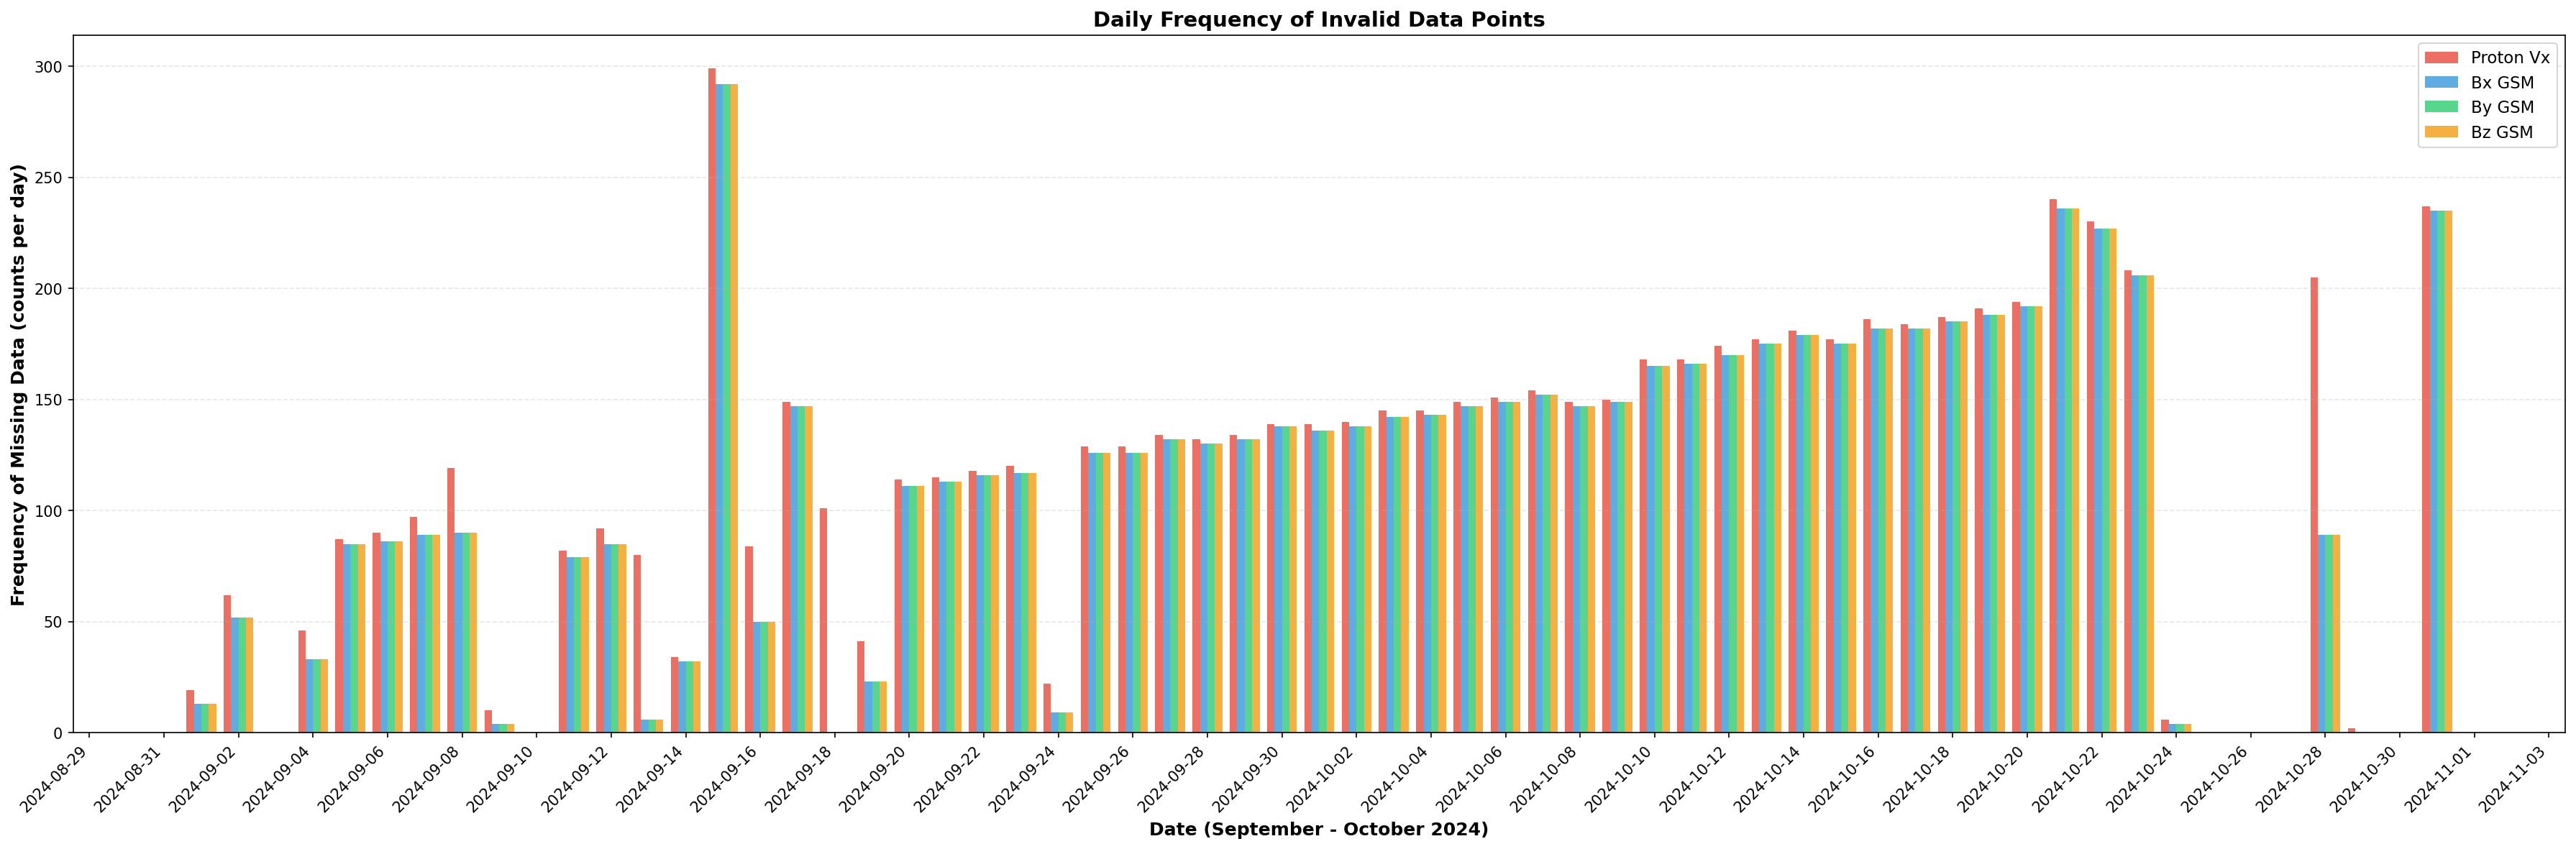

In [11]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib
matplotlib.use("Agg")
from PIL import Image
import pandas as pd
import numpy as np

conditions = ['proton_vx_gsm', 'bx_gsm', 'by_gsm', 'bz_gsm']
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
condition_labels = ['Proton Vx', 'Bx GSM', 'By GSM', 'Bz GSM']

# Add date column for grouping
df_sep_oct['date'] = df_sep_oct['time'].dt.date

# Calculate daily missing counts for each condition
daily_missing = {}

for i, cond in enumerate(conditions):
    is_invalid = df_sep_oct[cond].isna() | (df_sep_oct[cond] == 99999) | (df_sep_oct[cond] == -99999)
    df_sep_oct[f'{cond}_invalid'] = is_invalid

    # Group by date and count invalid
    daily_count = df_sep_oct.groupby('date')[f'{cond}_invalid'].sum()
    daily_missing[cond] = daily_count

# Create DataFrame for plotting
daily_df = pd.DataFrame(daily_missing)
daily_df.index = pd.to_datetime(daily_df.index)

# Plot
fig, ax = plt.subplots(figsize=(24, 8))

# Plot each condition
x = mdates.date2num(daily_df.index)
width = 0.2  # Width of bars

for i, cond in enumerate(conditions):
    offset = (i - 1.5) * width
    ax.bar(x + offset, daily_df[cond], width=width,
            label=condition_labels[i], color=colors[i], alpha=0.8)

# Format
ax.set_ylabel('Frequency of Missing Data (counts per day)', fontsize=12, fontweight='bold')
ax.set_xlabel('Date (September - October 2024)', fontsize=12, fontweight='bold')
ax.set_title('Daily Frequency of Invalid Data Points', fontsize=14, fontweight='bold')

# Format x-axis
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
plt.xticks(rotation=45, ha='right')

ax.legend(fontsize=11, loc='upper right')
ax.grid(True, axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('/users/framunno/visual_res/daily_missing_frequency.png', dpi=150, bbox_inches='tight')
plt.close()

# Print summary
print("Daily missing data statistics:")
print(f"\n{'Date':<12} {'Proton Vx':<12} {'Bx GSM':<12} {'By GSM':<12} {'Bz GSM':<12}")
print("-" * 60)
for date, row in daily_df.iterrows():
    if row.sum() > 0:  # Only show days with missing data
        print(f"{date.strftime('%Y-%m-%d'):<12} {int(row['proton_vx_gsm']):<12} {int(row['bx_gsm']):<12} {int(row['by_gsm']):<12} {int(row['bz_gsm']):<12}")

print(f"\n✓ Plot saved: /users/framunno/visual_res/daily_missing_frequency.png")
Image.open("/users/framunno/visual_res/daily_missing_frequency.png")